# Iteração 1 - Previsão de Recompra: Modelo RFM

Este projeto utiliza o dataset da Olist para construir um modelo de classificação que prevê se um cliente realizará uma segunda compra.

A primeira iteração utiliza apenas as features RFM: **Recência** (dias desde a última compra), **Frequência** (número de pedidos) e **Monetário** (valor total gasto). O objetivo é entender o comportamento de compra dos clientes a partir das features mais fundamentais antes de adicionar complexidade nas iterações seguintes.

Três abordagens são avaliadas: uma baseline ingênua, uma Decision Tree e uma Random Forest.

A variável alvo `target_repurchase` é binária: 1 se o cliente realizou uma segunda compra, 0 caso contrário.

## 1. Setup

In [ ]:
install.packages(c(
  "tidyverse", "caret", "randomForest",
  "pROC", "PRROC", "rpart", "rpart.plot", "reshape2", "knitr"
))

library(tidyverse)
library(caret)
library(randomForest)
library(pROC)
library(PRROC)
library(rpart)
library(rpart.plot)
library(reshape2)
library(knitr)

set.seed(811)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following 

## 2. Carregamento dos Dados

### 2.1 Leitura

In [ ]:
file_path <- "https://docs.google.com/spreadsheets/d/e/2PACX-1vQdpgjyNFJWX5VJO3A7I3x-fKuZ_2AU5zQxRa6_jpLQfeBUfLg3DBw5qCJvUkCvMMtpk1tZfrcK0gfM/pub?output=csv"
df_raw <- read.csv(file_path)

### 2.2 Seleção das Features RFM

In [ ]:
features_rfm <- c("recency_days", "total_orders", "total_spent")

df <- df_raw[, c(features_rfm, "target_repurchase")]

df$target_repurchase <- factor(df$target_repurchase,
                                levels = c(0, 1),
                                labels = c("Nao_recomprou", "Recomprou"))
dim(df)
str(df)

[1] 23658     4

'data.frame':	23658 obs. of  4 variables:
 $ recency_days     : int  204 75 50 44 252 56 44 195 188 241 ...
 $ total_orders     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ total_spent      : num  86.2 29 91.3 257.4 76.1 ...
 $ target_repurchase: Factor w/ 2 levels "Nao_recomprou",..: 1 1 1 1 1 1 1 1 1 1 ...


### 2.3 Distribuição do Target

In [ ]:
table(df$target_repurchase)
prop.table(table(df$target_repurchase)) * 100


Nao_recomprou     Recomprou 
        23105           553 


Nao_recomprou     Recomprou 
    97.662524      2.337476 

Taxa de recompra de ~2,3%. Dataset fortemente desbalanceado. Esse será o principal desafio desta iteração e vai impactar diretamente os resultados dos modelos.

## 3. Análise Exploratória

### 3.1 Estatísticas Descritivas

In [ ]:
summary(df[, features_rfm])

  recency_days    total_orders   total_spent     
 Min.   :  0.0   Min.   :1.00   Min.   :  10.07  
 1st Qu.: 56.0   1st Qu.:1.00   1st Qu.:  61.73  
 Median :108.0   Median :1.00   Median : 104.38  
 Mean   :114.2   Mean   :1.03   Mean   : 163.20  
 3rd Qu.:165.0   3rd Qu.:1.00   3rd Qu.: 178.25  
 Max.   :269.0   Max.   :6.00   Max.   :7571.63  

`total_orders` concentrado em 1 para a maioria dos clientes. `total_spent` apresenta a maior amplitude entre as features.

### 3.2 Boxplots

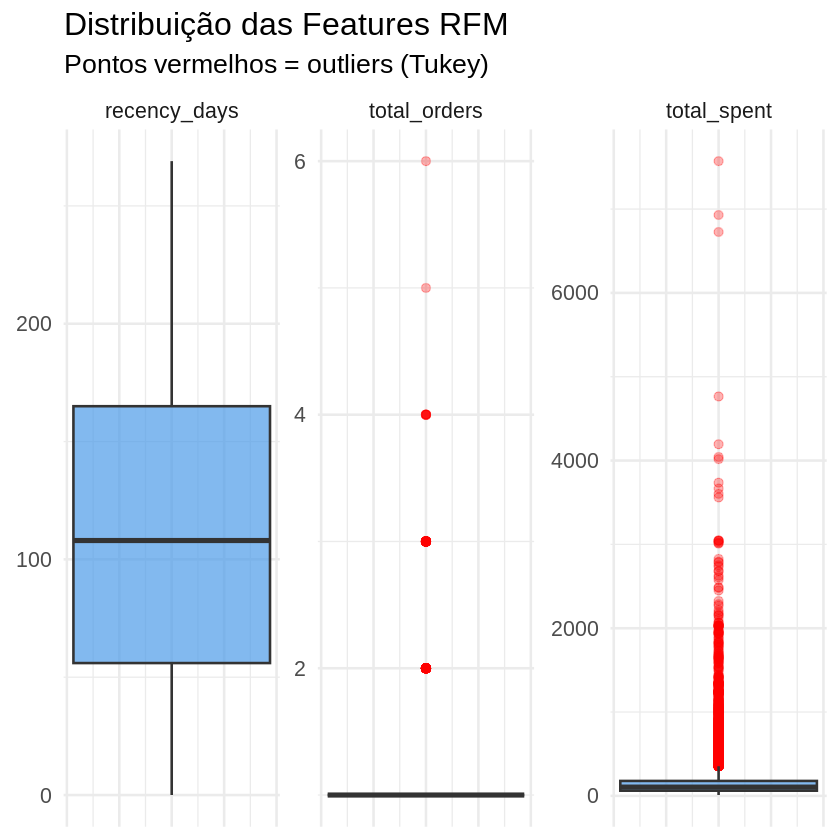

In [ ]:
df_long <- pivot_longer(
  select(df, all_of(features_rfm)),
  everything(),
  names_to  = "feature",
  values_to = "valor"
)

ggplot(df_long, aes(y = valor)) +
  geom_boxplot(fill = "#4C9BE8", alpha = 0.7,
               outlier.colour = "red", outlier.alpha = 0.3) +
  facet_wrap(~ feature, scales = "free_y") +
  labs(title    = "Distribuição das Features RFM",
       subtitle = "Pontos vermelhos = outliers (Tukey)",
       y = NULL, x = NULL) +
  theme_minimal(base_size = 16) +
  theme(axis.text.x  = element_blank(),
        axis.ticks.x = element_blank())

`total_spent` apresenta a maior concentração de outliers. `total_orders` visualmente concentrado em valores baixos.

### 3.3 Coeficiente de Variação

In [ ]:
cv <- sapply(df[, features_rfm], function(x) round(sd(x) / mean(x) * 100, 1))
print(cv)

recency_days total_orders  total_spent 
        59.2         18.6        142.5 


`total_spent` apresenta o maior coeficiente de variação. Grande dispersão relativa em relação à média.

### 3.4 Análise de Outliers (Tukey — observacional)

In [ ]:
outliers_summary <- function(x, nome) {
  Q1  <- quantile(x, 0.25)
  Q3  <- quantile(x, 0.75)
  IQR_val <- Q3 - Q1
  lower <- Q1 - 1.5 * IQR_val
  upper <- Q3 + 1.5 * IQR_val
  n_out <- sum(x < lower | x > upper)
  cat(nome, "\n")
  cat("  IQR:", round(IQR_val, 2),
      "| Limite inf:", round(lower, 2),
      "| Limite sup:", round(upper, 2), "\n")
  cat("  N outliers:", n_out,
      "| %:", round(n_out / length(x) * 100, 1), "%\n\n")
}

outliers_summary(df$recency_days, "R - recency_days")
outliers_summary(df$total_orders, "F - total_orders")
outliers_summary(df$total_spent,  "M - total_spent")

R - recency_days 
  IQR: 109 | Limite inf: -107.5 | Limite sup: 328.5 
  N outliers: 0 | %: 0 %

F - total_orders 
  IQR: 0 | Limite inf: 1 | Limite sup: 1 
  N outliers: 650 | %: 2.7 %

M - total_spent 
  IQR: 116.52 | Limite inf: -113.05 | Limite sup: 353.02 
  N outliers: 1934 | %: 8.2 %



Análise observacional, nada é removido aqui. O Tukey detecta outliers com base no IQR. Valores fora de Q1 - 1.5xIQR e Q3 + 1.5xIQR são marcados como outliers. `total_orders` apresenta IQR=0. 97% dos clientes têm 1 pedido. Com Tukey padrão, os limites colapsariam em [1,1] e todos os clientes com mais de 1 pedido seriam marcados como outlier. Esse comportamento será tratado adiante.

### 3.5 Histogramas

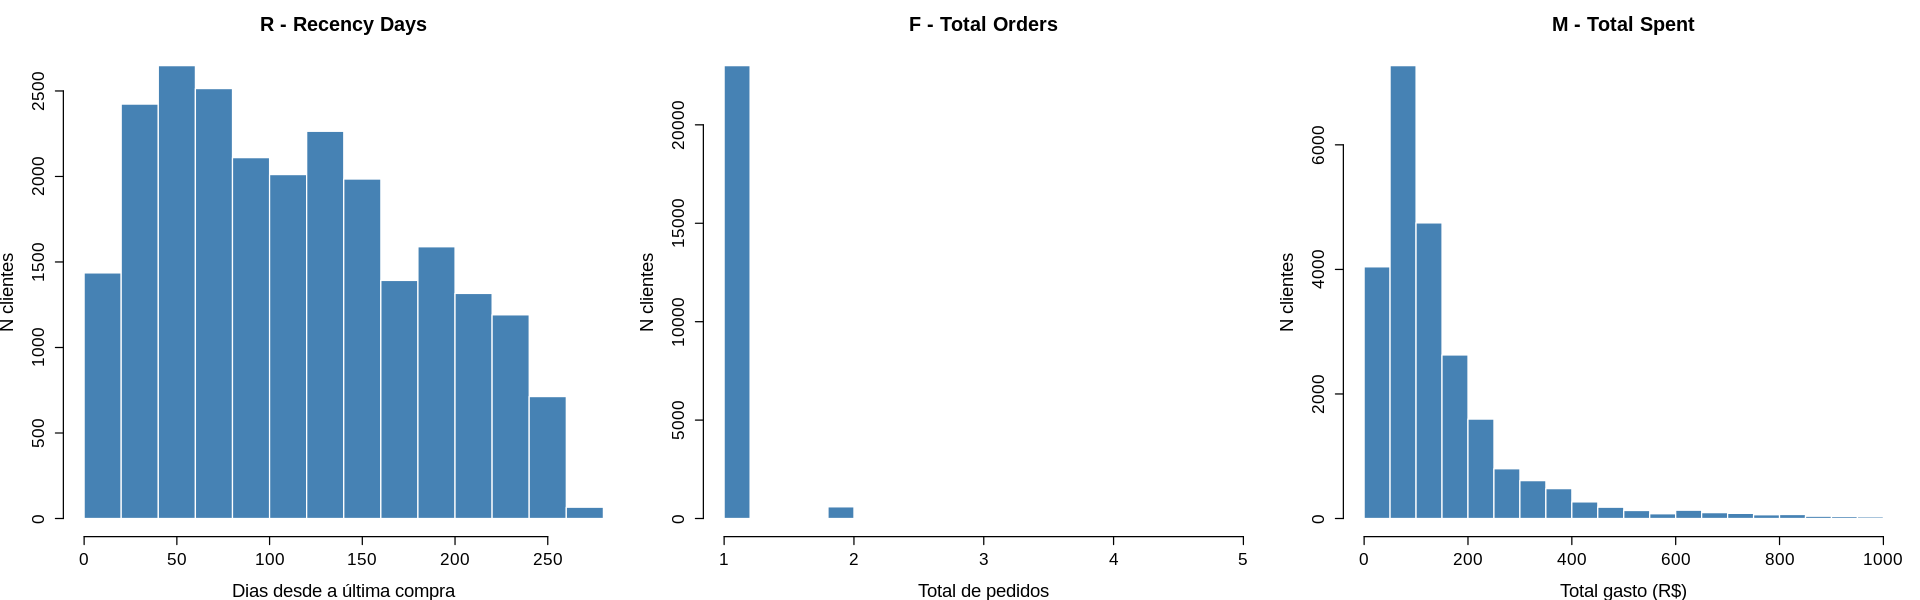

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 5)
par(mfrow = c(1, 3), mar = c(4, 4, 3, 1),
    cex.main = 1.5, cex.lab = 1.4, cex.axis = 1.3)

hist(df$recency_days,
     main  = "R - Recency Days",
     xlab  = "Dias desde a última compra",
     ylab  = "N clientes", col = "steelblue", border = "white")

hist(df$total_orders[df$total_orders <= 5],
     main  = "F - Total Orders",
     xlab  = "Total de pedidos",
     ylab  = "N clientes", col = "steelblue", border = "white",
     xlim  = c(1, 5))

hist(df$total_spent[df$total_spent <= 1000],
     main   = "M - Total Spent",
     xlab   = "Total gasto (R$)",
     ylab   = "N clientes", col = "steelblue", border = "white",
     breaks = seq(0, 1000, by = 50))

`recency_days` com distribuição próxima ao uniforme. `total_orders` concentrado em 1, barra do 2 quase invisível. `total_spent` com cauda longa à direita, maioria dos clientes entre `R$0` e `R$200`.

### 3.6 Comparação por Grupo Target

target_repurchase,recency_days,total_orders,total_spent
<fct>,"<dbl[,2]>","<dbl[,2]>","<dbl[,2]>"
Nao_recomprou,"114.51, 109","1.03, 1","163.43, 104.37"
Recomprou,"99.99, 90","1.10, 1","153.79, 107.07"


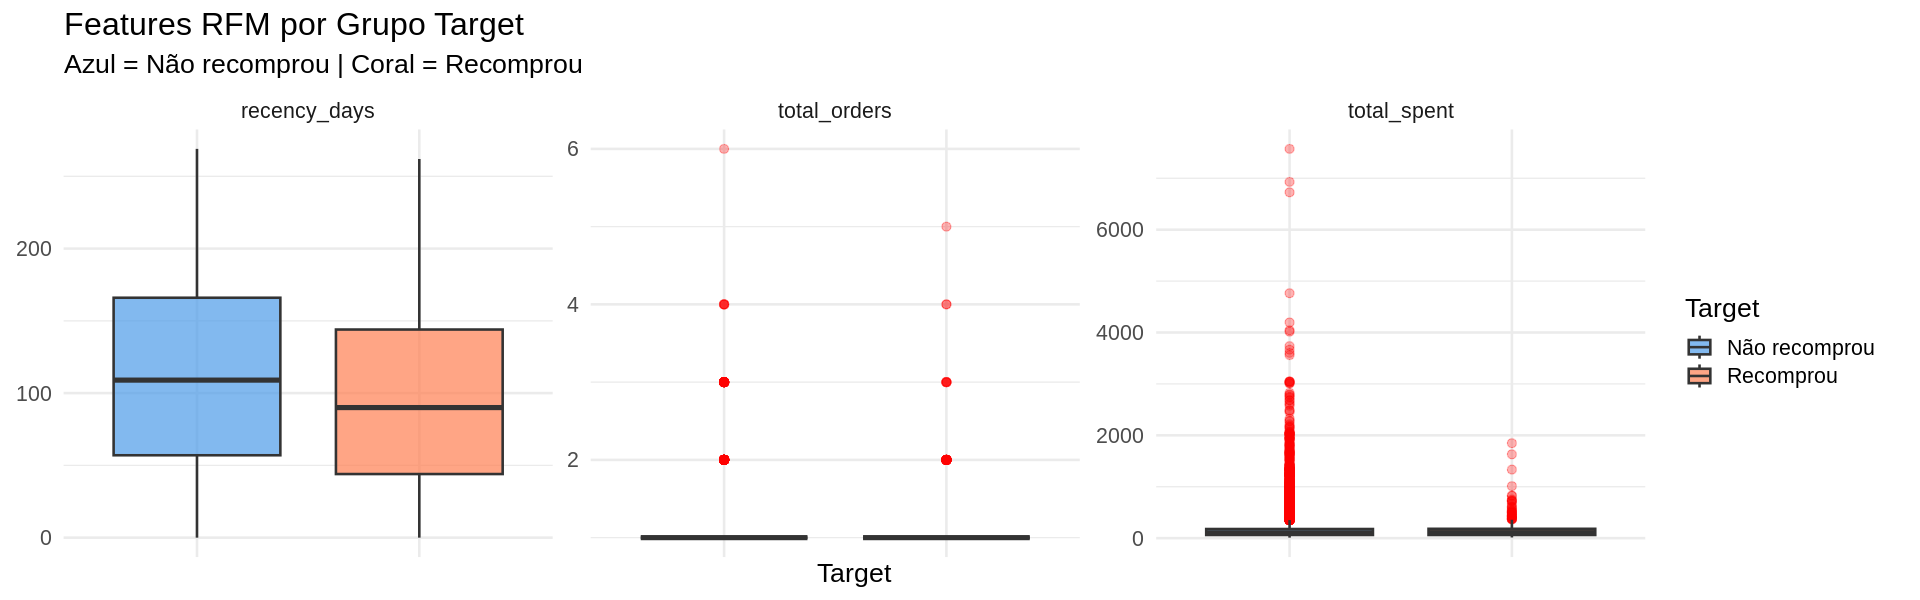

In [ ]:
df_long_target <- pivot_longer(
  select(df, all_of(features_rfm), target_repurchase),
  cols      = all_of(features_rfm),
  names_to  = "feature",
  values_to = "valor"
)

ggplot(df_long_target, aes(x = factor(target_repurchase), y = valor,
                           fill = factor(target_repurchase))) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.3) +
  facet_wrap(~ feature, scales = "free_y", ncol = 3) +
  scale_fill_manual(values = c("Nao_recomprou" = "#4C9BE8",
                               "Recomprou"     = "coral"),
                    labels  = c("Nao_recomprou" = "Não recomprou",
                                "Recomprou"     = "Recomprou")) +
  labs(title    = "Features RFM por Grupo Target",
       subtitle = "Azul = Não recomprou | Coral = Recomprou",
       x = "Target", y = NULL, fill = "Target") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x  = element_blank(),
        axis.ticks.x = element_blank())

aggregate(cbind(recency_days, total_orders, total_spent) ~ target_repurchase,
          data = df,
          FUN  = function(x) round(c(media = mean(x), mediana = median(x)), 2))

`recency_days` apresenta a separação visual mais clara entre os grupos. `total_orders` e `total_spent` mostram separação menos evidente.

### 3.7 Teste de Wilcoxon

In [ ]:
estatisticas_por_grupo <- function(feature) {
  grupo_nao <- df[[feature]][df$target_repurchase == "Nao_recomprou"]
  grupo_sim <- df[[feature]][df$target_repurchase == "Recomprou"]
  p_value   <- wilcox.test(df[[feature]] ~ df$target_repurchase)$p.value
  data.frame(
    feature      = feature,
    media_nao    = round(mean(grupo_nao), 2),
    media_sim    = round(mean(grupo_sim), 2),
    sd_nao       = round(sd(grupo_nao),   2),
    sd_sim       = round(sd(grupo_sim),   2),
    p_value      = round(p_value, 4),
    significativo = ifelse(p_value < 0.05, "Sim", "Nao")
  )
}

tabela_estatistica <- do.call(rbind, lapply(features_rfm, estatisticas_por_grupo))
print(tabela_estatistica)

       feature media_nao media_sim sd_nao sd_sim p_value significativo
1 recency_days    114.51     99.99  67.63  66.09  0.0000           Sim
2 total_orders      1.03      1.10   0.18   0.39  0.0000           Sim
3  total_spent    163.43    153.79 233.74 172.25  0.8446           Nao


Teste não-paramétrico usado por conta das distribuições assimétricas. As três features apresentam diferença estatisticamente significativa entre os grupos (p < 0,05). `recency_days` mostra a maior diferença entre médias.

### 3.8 Matriz de Correlação



Table: Matriz de Correlação RFM (Spearman)

|             | recency_days| total_orders| total_spent|
|:------------|------------:|------------:|-----------:|
|recency_days |         1.00|        -0.05|       -0.01|
|total_orders |        -0.05|         1.00|        0.15|
|total_spent  |        -0.01|         0.15|        1.00|

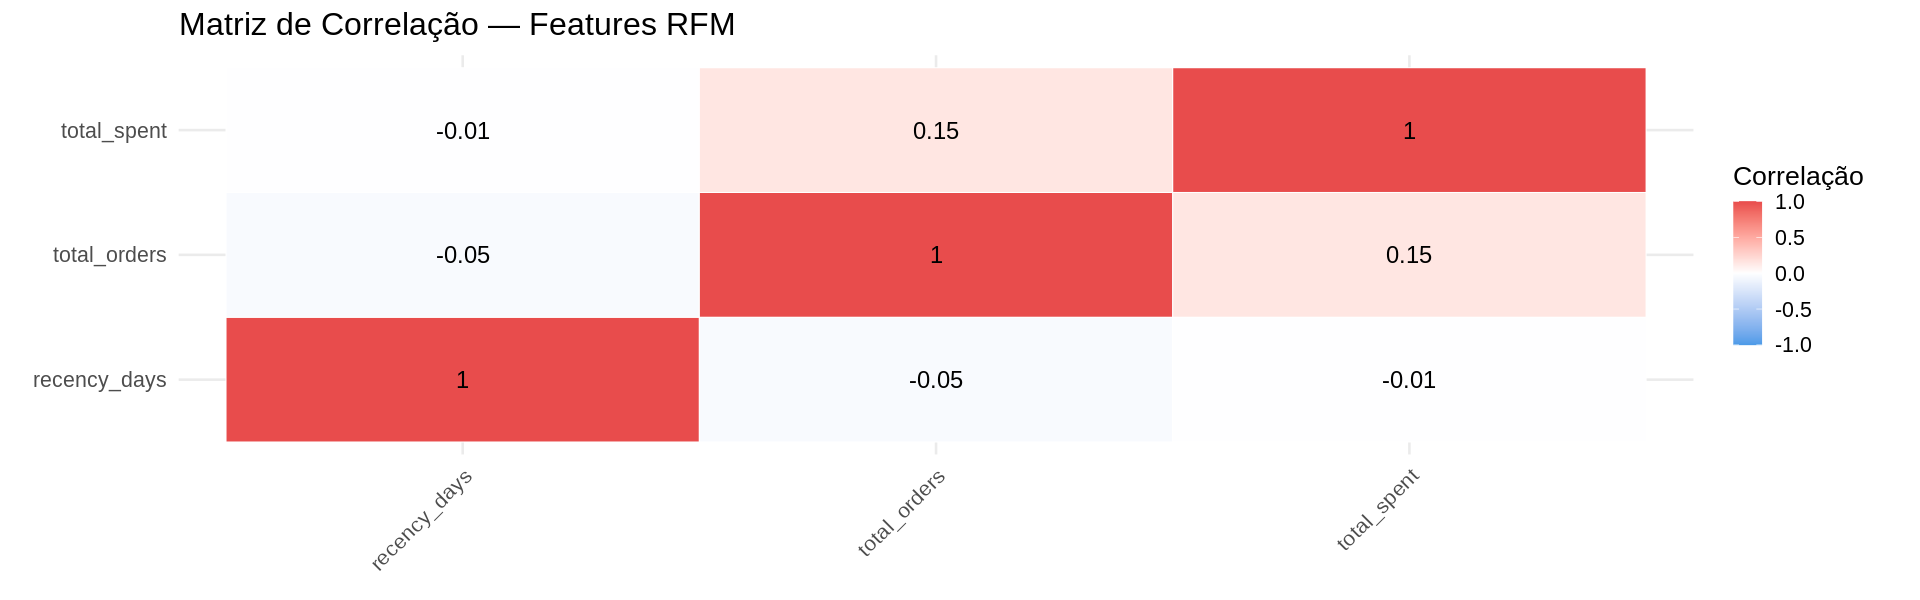

In [ ]:
cor_matrix <- cor(df[, features_rfm], method = "spearman")
cor_melted  <- melt(cor_matrix)

ggplot(cor_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(value, 2)), size = 5) +
  scale_fill_gradient2(low = "#4C9BE8", mid = "white", high = "#E84C4C",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Matriz de Correlação — Features RFM",
       x = NULL, y = NULL, fill = "Correlação") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

kable(round(cor_matrix, 2), caption = "Matriz de Correlação RFM (Spearman)")

Correlações baixas entre todas as features. Cada feature traz informação relativamente independente para o modelo.

## 4. Preparação dos Dados

### 4.1 Divisão Treino / Teste (70/30)

In [ ]:
set.seed(811)
indices <- createDataPartition(df$target_repurchase, p = 0.70, list = FALSE)
treino  <- df[indices, ]
teste   <- df[-indices, ]

cat("Treino:", nrow(treino), "linhas\n")
cat("Teste: ", nrow(teste),  "linhas\n\n")

cat("Proporção target — Treino:\n")
print(round(prop.table(table(treino$target_repurchase)) * 100, 2))

cat("\nProporção target — Teste:\n")
print(round(prop.table(table(teste$target_repurchase)) * 100, 2))

treino_antes <- treino

Treino: 16562 linhas
Teste:  7096 linhas

Proporção target — Treino:

Nao_recomprou     Recomprou 
        97.66          2.34 

Proporção target — Teste:

Nao_recomprou     Recomprou 
        97.67          2.33 


Divisão 70/30 mantendo a proporção original do target em ambos os conjuntos via `createDataPartition`.

### 4.2 Verificação de Sobreposição

In [ ]:
linhas_comuns <- intersect(rownames(treino), rownames(teste))
cat("Linhas em comum entre treino e teste:", length(linhas_comuns), "\n")

Linhas em comum entre treino e teste: 0 


### 4.3 Remoção de Outliers

In [ ]:
tukey_limites_safe <- function(x, nome = "") {
  Q1      <- quantile(x, 0.25)
  Q3      <- quantile(x, 0.75)
  IQR_val <- Q3 - Q1

  if (IQR_val == 0) {
    lower <- quantile(x, 0.01)
    upper <- quantile(x, 0.99)
    cat("AVISO: IQR=0 em '", nome, "' usando p1/p99: [",
        round(lower, 2), ",", round(upper, 2), "]\n", sep = "")
  } else {
    lower <- Q1 - 1.5 * IQR_val
    upper <- Q3 + 1.5 * IQR_val
  }
  list(lower = lower, upper = upper)
}

features_num <- c("recency_days", "total_orders", "total_spent")

limites <- lapply(features_num, function(f) tukey_limites_safe(treino[[f]], f))
names(limites) <- features_num

for (f in features_num) {
  treino <- treino[
    treino[[f]] >= limites[[f]]$lower &
    treino[[f]] <= limites[[f]]$upper, ]
}

cat("Treino antes da remoção:", nrow(treino_antes), "\n")
cat("Treino após remoção:    ", nrow(treino), "\n")
cat("Clientes removidos:     ", nrow(treino_antes) - nrow(treino),
    "(", round((nrow(treino_antes) - nrow(treino)) / nrow(treino_antes) * 100, 1), "%)\n\n")
cat("Teste mantido intacto: ", nrow(teste), "clientes\n\n")

for (f in features_num) {
  cat(f, "limite inf:", round(limites[[f]]$lower, 2),
      "| sup:", round(limites[[f]]$upper, 2), "\n")
}

AVISO: IQR=0 em 'total_orders' usando p1/p99: [1,2]
Treino antes da remoção: 16562 
Treino após remoção:     15137 
Clientes removidos:      1425 ( 8.6 %)

Teste mantido intacto:  7096 clientes

recency_days limite inf: -109 | sup: 331 
total_orders limite inf: 1 | sup: 2 
total_spent limite inf: -111.01 | sup: 348.9 


### 4.4 Distribuição do Treino — Antes da Remoção

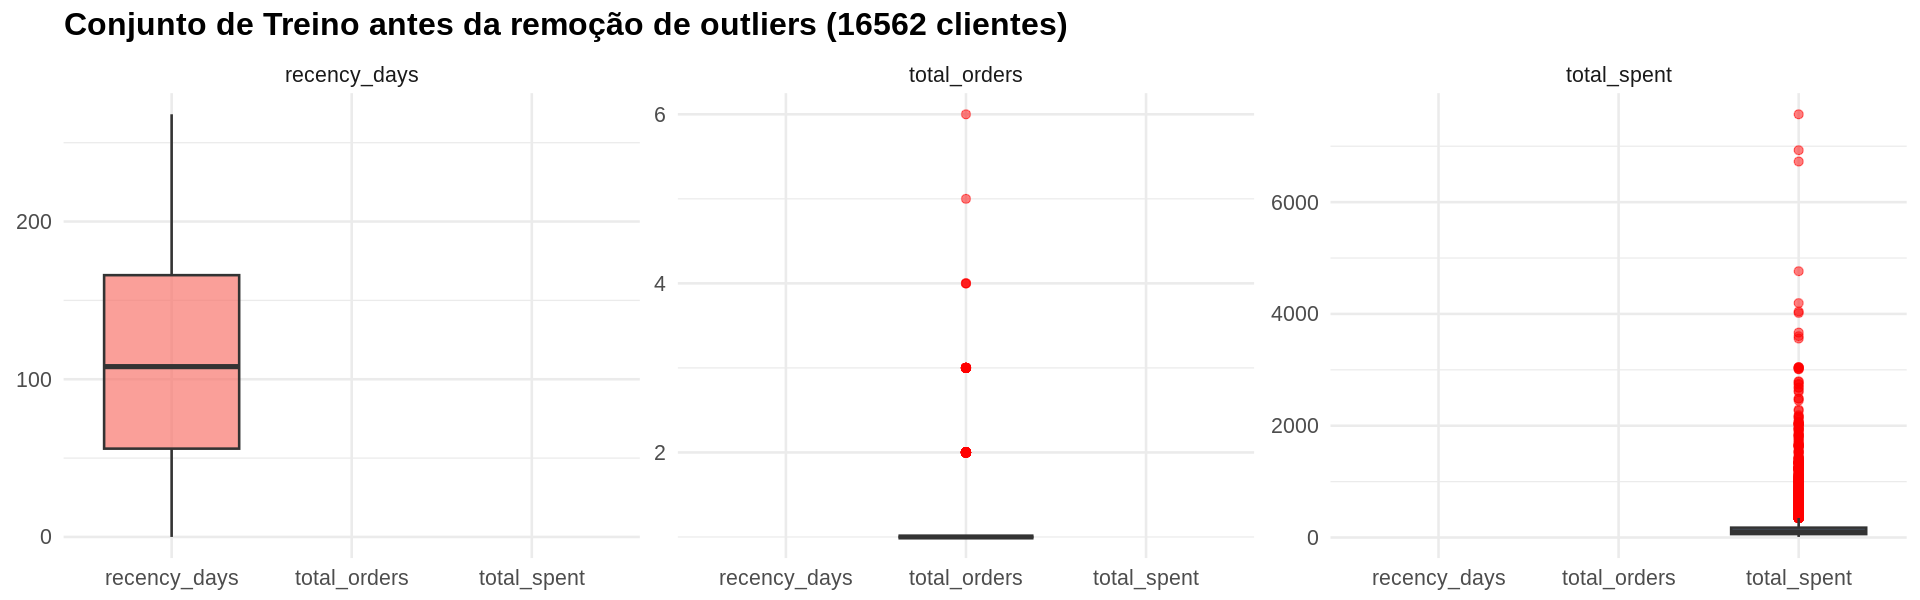

In [ ]:
treino_antes %>%
  pivot_longer(cols = all_of(features_num),
               names_to = "feature", values_to = "valor") %>%
  ggplot(aes(x = feature, y = valor, fill = feature)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.5) +
  facet_wrap(~ feature, scales = "free_y") +
  labs(title = paste0("Conjunto de Treino antes da remoção de outliers (",
                      nrow(treino_antes), " clientes)"),
       x = NULL, y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"),
        legend.position = "none")

### 4.5 Distribuição do Treino — Após Remoção

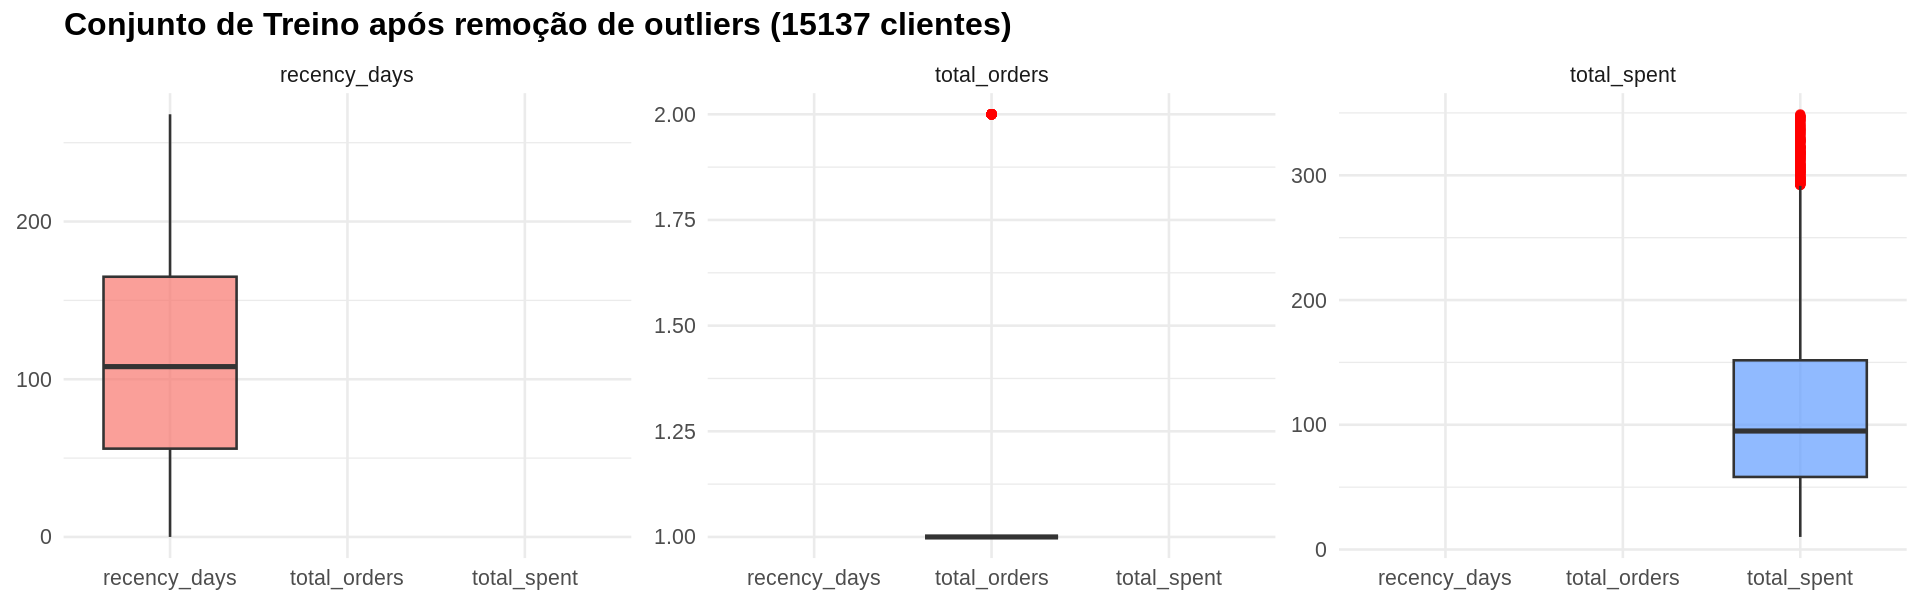

In [ ]:
treino %>%
  pivot_longer(cols = all_of(features_num),
               names_to = "feature", values_to = "valor") %>%
  ggplot(aes(x = feature, y = valor, fill = feature)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.5) +
  facet_wrap(~ feature, scales = "free_y") +
  labs(title = paste0("Conjunto de Treino após remoção de outliers (",
                      nrow(treino), " clientes)"),
       x = NULL, y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"),
        legend.position = "none")

Remoção aplicada exclusivamente no conjunto de treino para evitar data leakage. `total_orders` ativou o fallback p1/p99 por ter IQR=0, preservando clientes com até 2 pedidos. `total_spent` com limite superior em `R$348,90`. No total 1.425 clientes removidos do treino (8,6%). Teste mantido intacto.

### 4.6 Correlação no Treino



Table: Correlação Spearman — Treino

|             | recency_days| total_orders| total_spent|
|:------------|------------:|------------:|-----------:|
|recency_days |         1.00|        -0.03|       -0.01|
|total_orders |        -0.03|         1.00|        0.12|
|total_spent  |        -0.01|         0.12|        1.00|

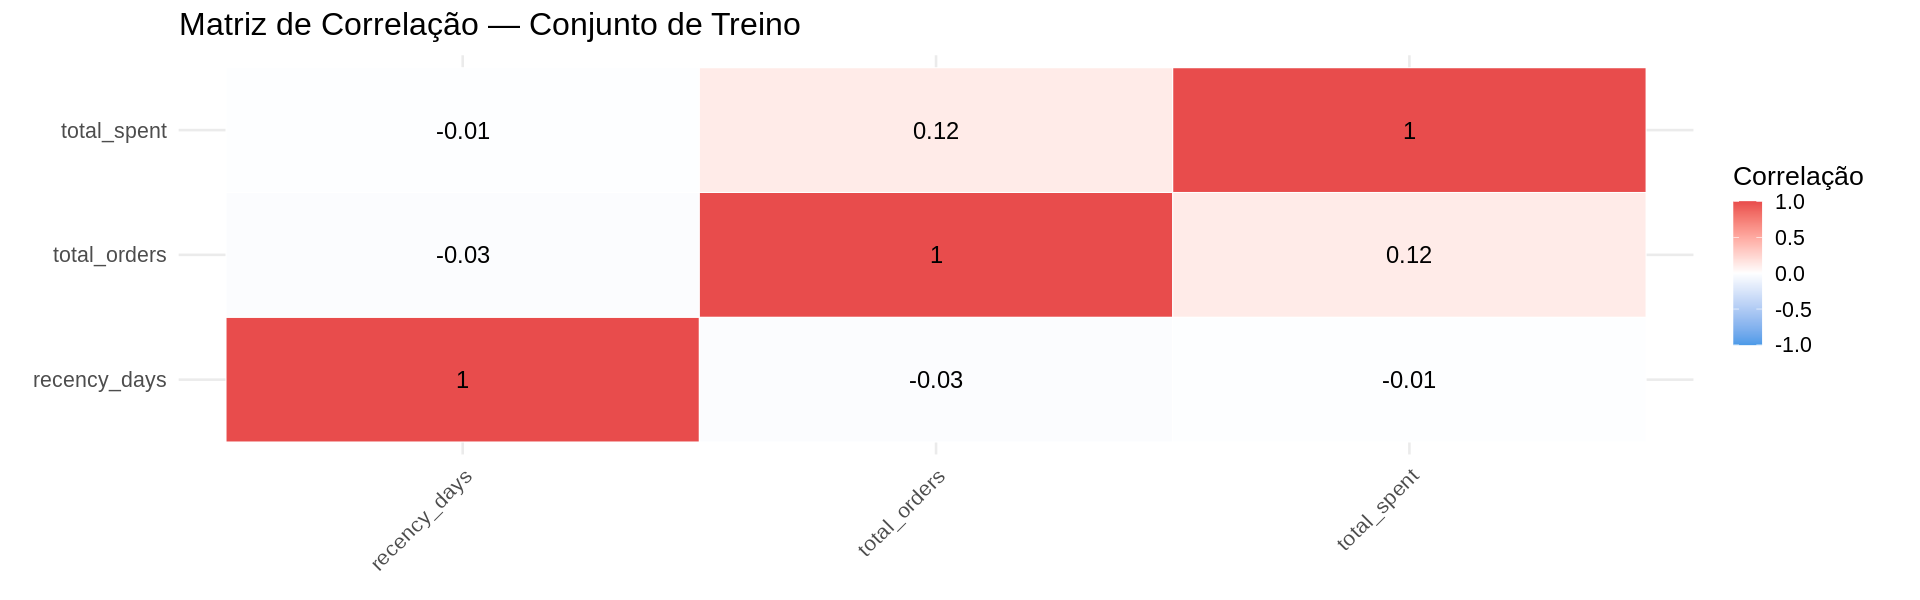

In [ ]:
features_cor <- features_rfm[sapply(treino[, features_rfm],
                                     function(x) sd(x) > 0)]

if (length(features_rfm) != length(features_cor)) {
  excluidas <- setdiff(features_rfm, features_cor)
  cat("\nVariáveis com variância zero no treino (excluídas da matriz):",
      paste(excluidas, collapse = ", "), "\n\n")
}

cor_matrix_treino <- cor(treino[, features_cor], method = "spearman")

cor_melted_treino <- melt(cor_matrix_treino)

ggplot(cor_melted_treino, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(value, 2)), size = 5) +
  scale_fill_gradient2(low = "#4C9BE8", mid = "white", high = "#E84C4C",
                       midpoint = 0, limits = c(-1, 1)) +
  labs(title = "Matriz de Correlação — Conjunto de Treino",
       x = NULL, y = NULL, fill = "Correlação") +
  theme_minimal(base_size = 16) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

kable(round(cor_matrix_treino, 2), caption = "Correlação Spearman — Treino")

Correlações baixas entre todas as features no conjunto de treino. A maior correlação observada é entre `total_orders` e `total_spent` (0.12), classificada como fraca.

### 4.7 Class Weights

In [ ]:
n_nao  <- sum(treino$target_repurchase == "Nao_recomprou")
n_sim  <- sum(treino$target_repurchase == "Recomprou")
ratio  <- n_nao / n_sim

cat("\nDistribuição do treino:\n")
cat("  Nao_recomprou:", n_nao, "\n")
cat("  Recomprou:    ", n_sim,  "\n")
cat("  Peso aplicado a Recomprou:", round(ratio, 1), "x\n")

pesos_treino <- ifelse(treino$target_repurchase == "Recomprou", ratio, 1)


Distribuição do treino:
  Nao_recomprou: 14778 
  Recomprou:     359 
  Peso aplicado a Recomprou: 41.2 x


Em vez de remover dados via downsampling, os modelos recebem pesos inversamente proporcionais à frequência de cada classe. A classe Recomprou recebe peso 41.2x maior, mantendo todos os 15.137 clientes do treino disponíveis.

## 5. Baseline Ingênua

In [ ]:
baseline <- rep("Nao_recomprou", nrow(teste))
baseline <- factor(baseline, levels = levels(teste$target_repurchase))

cm_base <- confusionMatrix(baseline, teste$target_repurchase,
                            positive = "Recomprou")
print(cm_base)

Confusion Matrix and Statistics

               Reference
Prediction      Nao_recomprou Recomprou
  Nao_recomprou          6931       165
  Recomprou                 0         0
                                         
               Accuracy : 0.9767         
                 95% CI : (0.973, 0.9801)
    No Information Rate : 0.9767         
    P-Value [Acc > NIR] : 0.5207         
                                         
                  Kappa : 0              
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 0.00000        
            Specificity : 1.00000        
         Pos Pred Value :     NaN        
         Neg Pred Value : 0.97675        
             Prevalence : 0.02325        
         Detection Rate : 0.00000        
   Detection Prevalence : 0.00000        
      Balanced Accuracy : 0.50000        
                                         
       'Positive' Class 

A baseline classifica todos os clientes como não recompradores. Accuracy de 97,7% mas Recall = 0. Os 165 recompradores reais no teste não são identificados.

> **Nota:** com 2,3% de recompradores e apenas features RFM, os modelos desta iteração tendem a ficar próximos do aleatório. Os resultados a seguir devem ser lidos com essa restrição em mente.

## 6. Decision Tree

### 6.1 Treino

In [ ]:
set.seed(811)
ctrl_cv <- trainControl(
  method          = "repeatedcv",
  number          = 5,
  repeats         = 3,
  classProbs      = TRUE,
  summaryFunction = twoClassSummary
)

set.seed(811)
dt_model <- train(
  target_repurchase ~ .,
  data      = treino,
  method    = "rpart",
  trControl = ctrl_cv,
  metric    = "ROC",
  tuneGrid  = data.frame(cp = seq(0.001, 0.05, length.out = 10)),
  weights   = pesos_treino
)

cat("Melhor cp:", dt_model$bestTune$cp, "\n")

Melhor cp: 0.01188889 


### 6.2 Tuning do cp

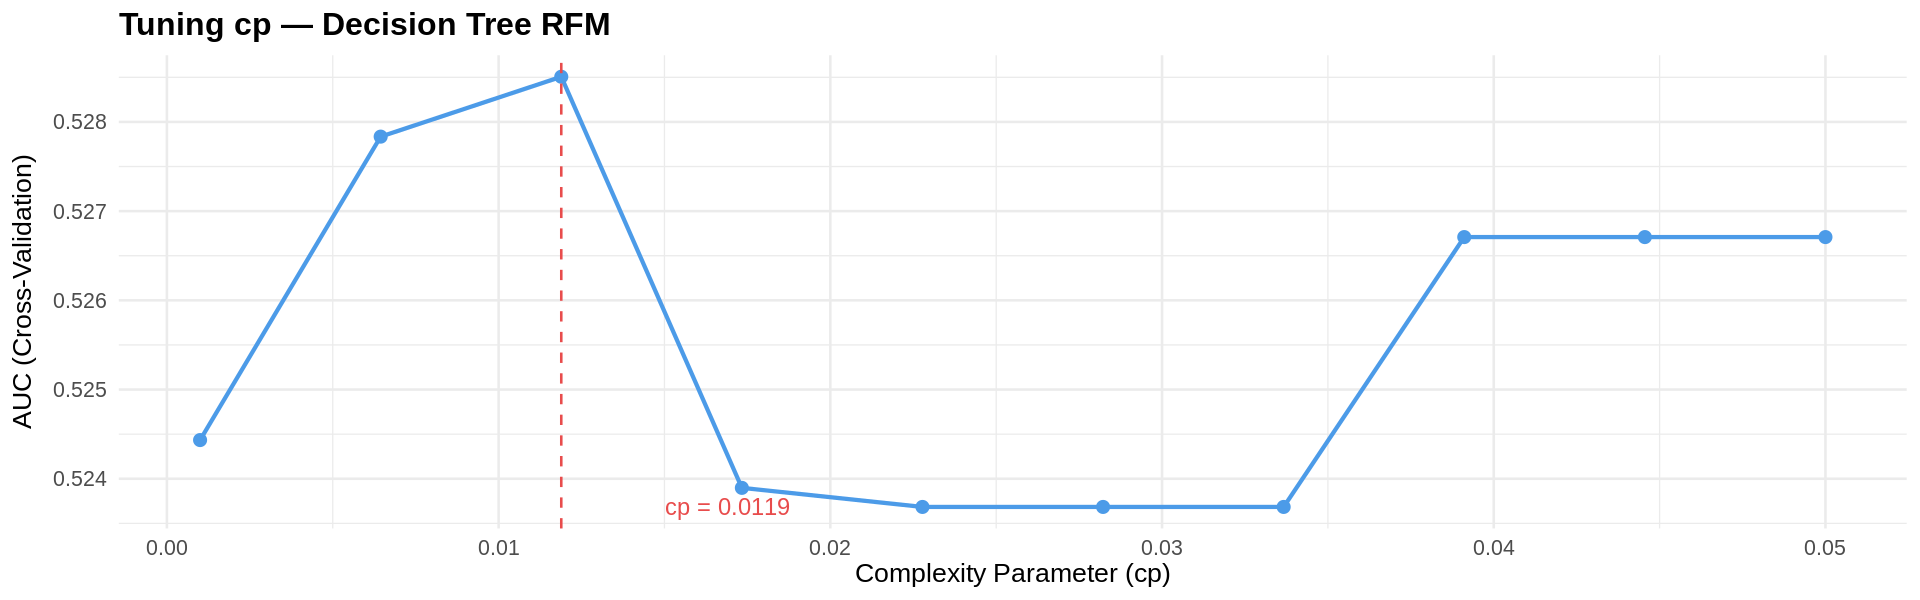

In [ ]:
ggplot(dt_model$results, aes(x = cp, y = ROC)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_point(color = "#4C9BE8", size = 3) +
  geom_vline(xintercept = dt_model$bestTune$cp,
             linetype = "dashed", color = "#E84C4C") +
  annotate("text",
           x = dt_model$bestTune$cp + 0.005,
           y = min(dt_model$results$ROC),
           label = paste0("cp = ", round(dt_model$bestTune$cp, 4)),
           color = "#E84C4C", size = 5) +
  labs(title = "Tuning cp — Decision Tree RFM",
       x     = "Complexity Parameter (cp)",
       y     = "AUC (Cross-Validation)") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

O cross-validation testou 10 valores de cp entre 0.001 e 0.05. O cp selecionado foi 0.0119. Valores maiores de cp estão associados a queda de desempenho nos folds.

### 6.3 Visualização da Árvore

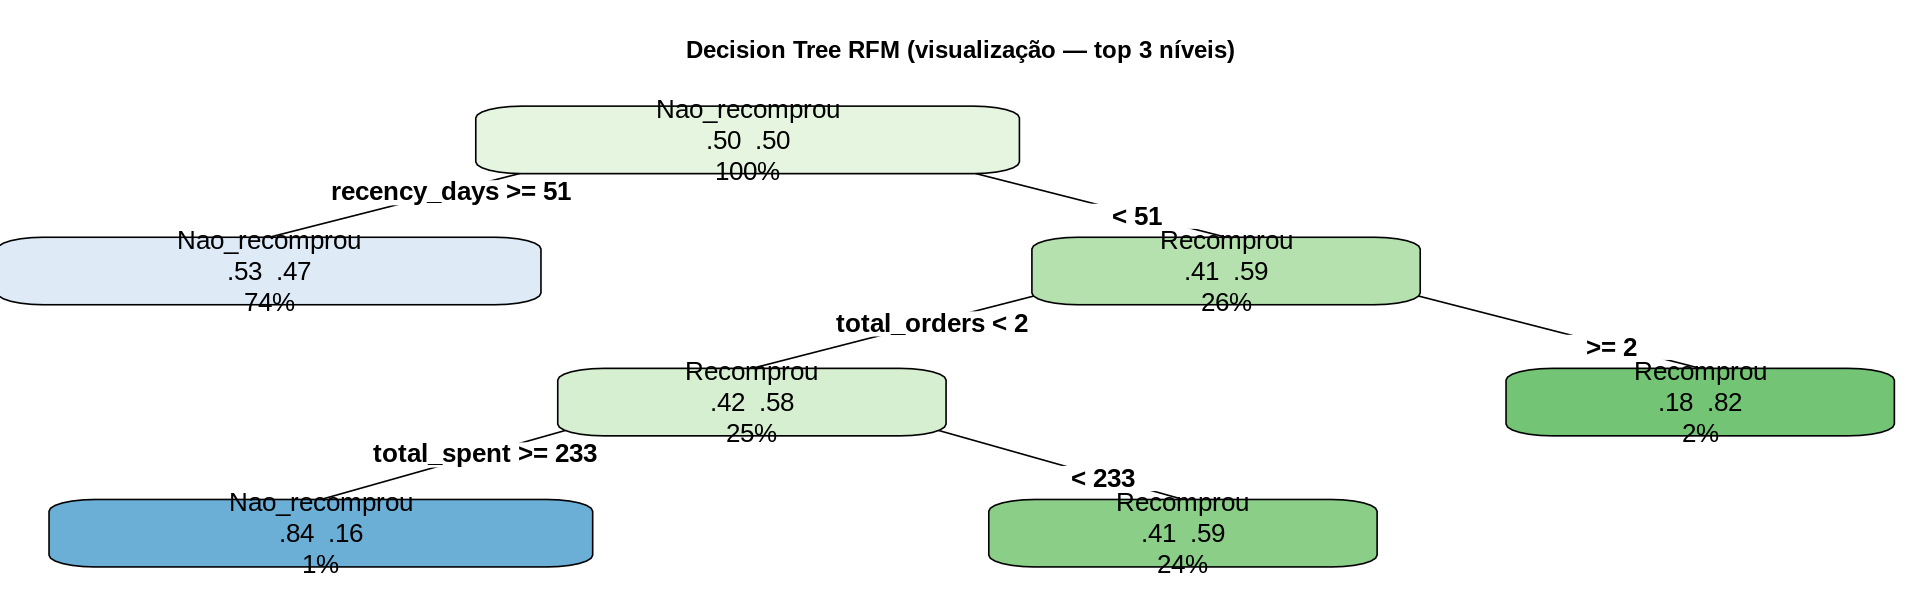

In [ ]:
set.seed(811)
dt_viz <- rpart(target_repurchase ~ .,
                data    = treino,
                method  = "class",
                control = rpart.control(maxdepth = 3, cp = 0.001),
                weights = pesos_treino)

rpart.plot(dt_viz,
           main          = "Decision Tree RFM (visualização — top 3 níveis)",
           type          = 4,
           extra         = 104,
           fallen.leaves = FALSE,
           tweak         = 1.3)

`recency_days >= 51` é o primeiro critério de divisão. Nos nós seguintes aparecem `total_orders` e `total_spent`, consistente com os resultados do Wilcoxon.

### 6.4 Confusion Matrix

Confusion Matrix and Statistics

               Reference
Prediction      Nao_recomprou Recomprou
  Nao_recomprou          5425       123
  Recomprou              1506        42
                                          
               Accuracy : 0.7704          
                 95% CI : (0.7605, 0.7802)
    No Information Rate : 0.9767          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.0073          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.254545        
            Specificity : 0.782715        
         Pos Pred Value : 0.027132        
         Neg Pred Value : 0.977830        
             Prevalence : 0.023253        
         Detection Rate : 0.005919        
   Detection Prevalence : 0.218151        
      Balanced Accuracy : 0.518630        
                                          
     

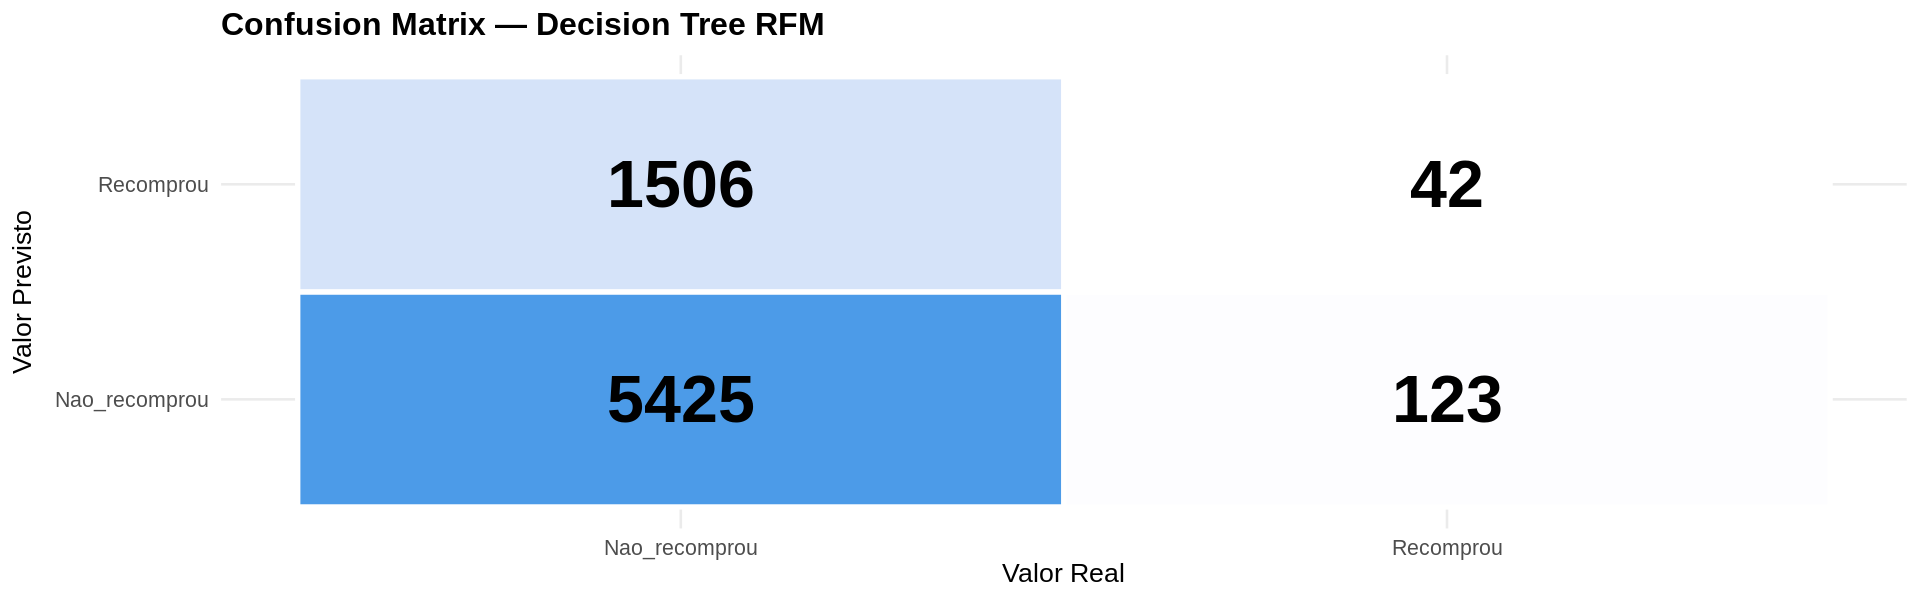

In [ ]:
pred_dt <- predict(dt_model, newdata = teste)

cm_dt <- confusionMatrix(pred_dt, teste$target_repurchase,
                         positive = "Recomprou")
print(cm_dt)

cm_table_dt <- as.data.frame(cm_dt$table)

ggplot(cm_table_dt, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(colour = "white", linewidth = 1.5) +
  geom_text(aes(label = Freq), size = 14, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "#4C9BE8") +
  labs(title = "Confusion Matrix — Decision Tree RFM",
       x     = "Valor Real", y = "Valor Previsto") +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none",
        plot.title      = element_text(face = "bold"))

42 recompradores reais identificados. 1.506 falsos positivos gerados. Para cada recomprador identificado, ~36 contactos desnecessários.

### 6.5 Métricas

In [ ]:
precision_dt <- cm_dt$byClass["Pos Pred Value"]
recall_dt    <- cm_dt$byClass["Sensitivity"]
f1_dt        <- 2 * (precision_dt * recall_dt) / (precision_dt + recall_dt)
accuracy_dt  <- cm_dt$overall["Accuracy"]

cat("Accuracy: ", round(accuracy_dt,  4), "\n")
cat("Precision:", round(precision_dt, 4), "\n")
cat("Recall:   ", round(recall_dt,    4), "\n")
cat("F1-Score: ", round(f1_dt,        4), "\n")

Accuracy:  0.7704 
Precision: 0.0271 
Recall:    0.2545 
F1-Score:  0.049 


Recall de 25,5%. 1 em cada 4 recompradores reais identificados. Precision de 2,7%. De cada 100 sinalizados, ~3 são recompradores reais.

### 6.6 ROC Curve

Setting direction: controls < cases



ROC-AUC — Decision Tree: 0.5186 


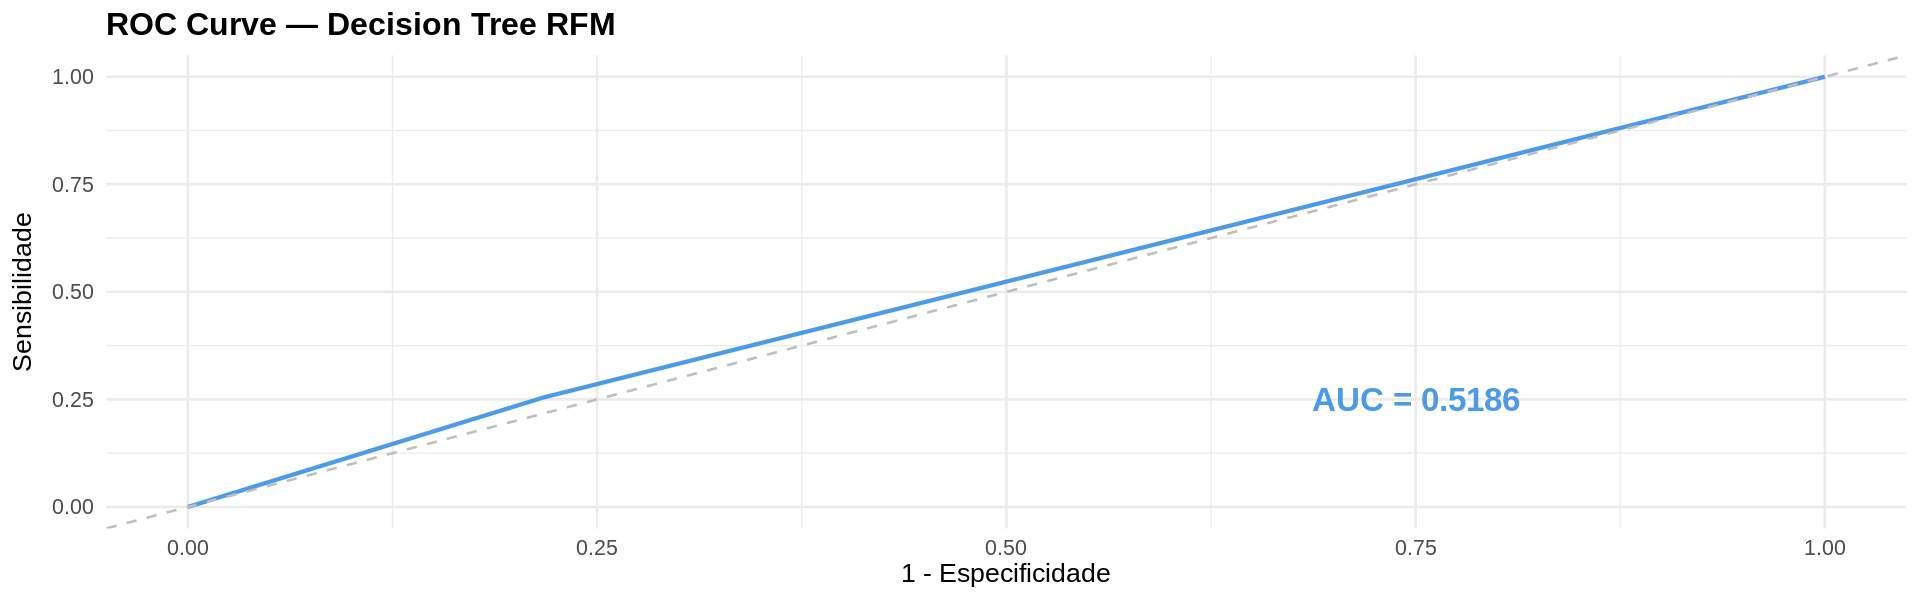

In [ ]:
prob_dt <- predict(dt_model, newdata = teste, type = "prob")[, "Recomprou"]

roc_dt <- roc(teste$target_repurchase, prob_dt,
              levels = c("Nao_recomprou", "Recomprou"))
auc_dt_roc <- round(auc(roc_dt), 4)
cat("ROC-AUC — Decision Tree:", auc_dt_roc, "\n")

roc_df_dt <- data.frame(
  specificity = rev(roc_dt$specificities),
  sensitivity = rev(roc_dt$sensitivities)
)

ggplot(roc_df_dt, aes(x = 1 - specificity, y = sensitivity)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
  annotate("text", x = 0.75, y = 0.25,
           label = paste0("AUC = ", auc_dt_roc),
           size = 7, color = "#4C9BE8", fontface = "bold") +
  labs(title = "ROC Curve — Decision Tree RFM",
       x     = "1 - Especificidade",
       y     = "Sensibilidade") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

ROC-AUC de 0.52. Próxima de 0.50 (aleatório). A PR-AUC será a métrica de referência dado o desbalanceamento do dataset.

### 6.7 PR Curve

PR-AUC  — Decision Tree: 0.025 
Baseline PR-AUC (random): 0.0233 


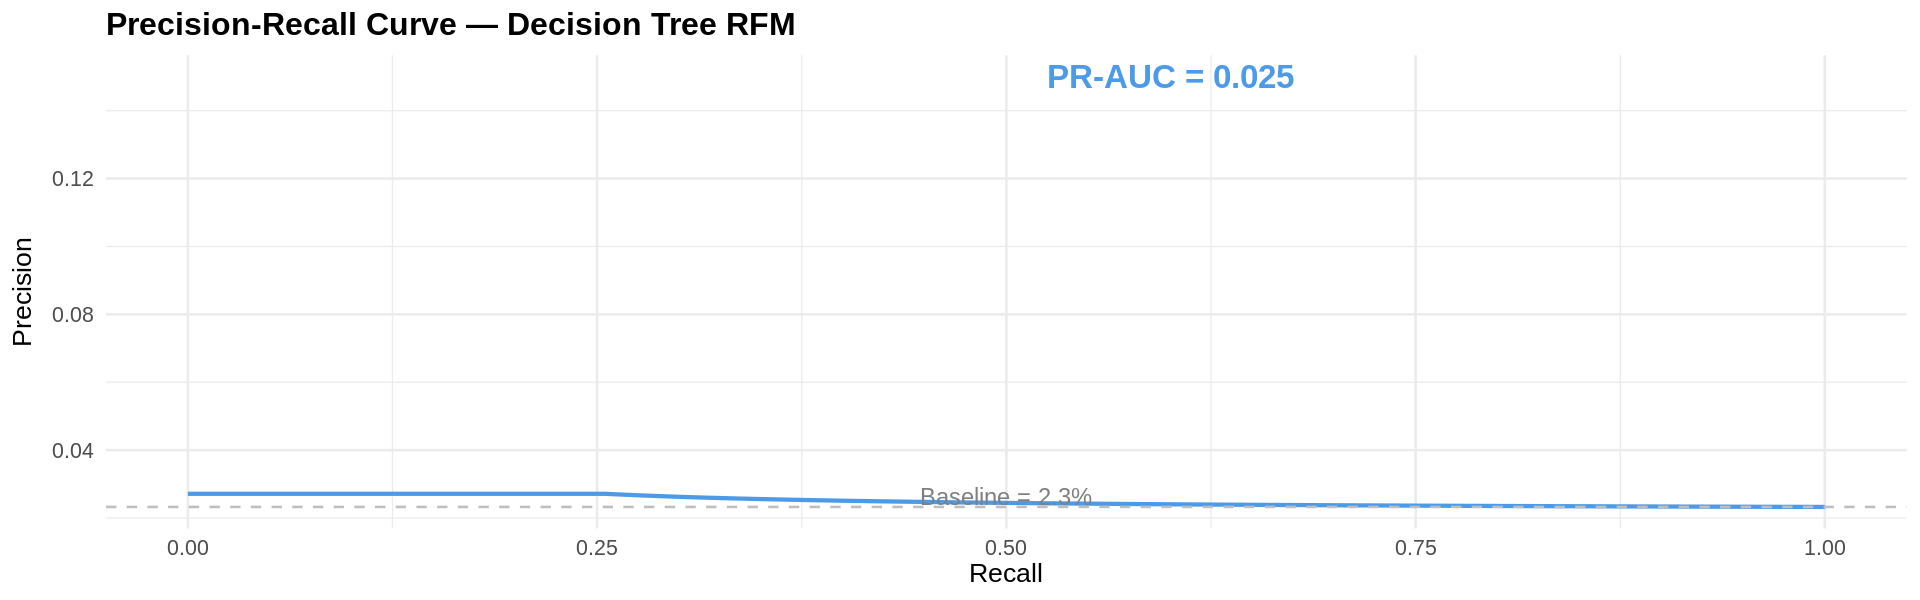

In [ ]:
baseline_pr <- mean(teste$target_repurchase == "Recomprou")

pr_dt <- pr.curve(
  scores.class0 = prob_dt[teste$target_repurchase == "Recomprou"],
  scores.class1 = prob_dt[teste$target_repurchase == "Nao_recomprou"],
  curve         = TRUE
)
auc_dt_pr <- round(pr_dt$auc.integral, 4)
cat("PR-AUC  — Decision Tree:", auc_dt_pr, "\n")
cat("Baseline PR-AUC (random):", round(baseline_pr, 4), "\n")

pr_df_dt <- data.frame(
  recall    = pr_dt$curve[, 1],
  precision = pr_dt$curve[, 2]
)

ggplot(pr_df_dt, aes(x = recall, y = precision)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_hline(yintercept = baseline_pr,
             linetype = "dashed", color = "gray") +
  annotate("text", x = 0.5, y = baseline_pr + 0.003,
           label = paste0("Baseline = ", round(baseline_pr * 100, 1), "%"),
           color = "gray50", size = 5) +
  annotate("text", x = 0.6, y = 0.15,
           label = paste0("PR-AUC = ", auc_dt_pr),
           size = 7, color = "#4C9BE8", fontface = "bold") +
  labs(title = "Precision-Recall Curve — Decision Tree RFM",
       x     = "Recall", y = "Precision") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

PR-AUC de 0.025 contra baseline de 0.023. Ganho marginal sobre o aleatório. Para datasets desbalanceados, a PR-AUC é a métrica de referência.

## 7. Random Forest

### 7.1 Treino

In [ ]:
set.seed(811)
rf_model <- train(
  target_repurchase ~ .,
  data       = treino,
  method     = "rf",
  trControl  = ctrl_cv,
  metric     = "ROC",
  tuneLength = 5,
  classwt    = c("Nao_recomprou" = 1, "Recomprou" = ratio)
)

cat("Melhor mtry:", rf_model$bestTune$mtry, "\n")

note: only 2 unique complexity parameters in default grid. Truncating the grid to 2 .

Melhor mtry: 2 


### 7.2 Tuning do mtry

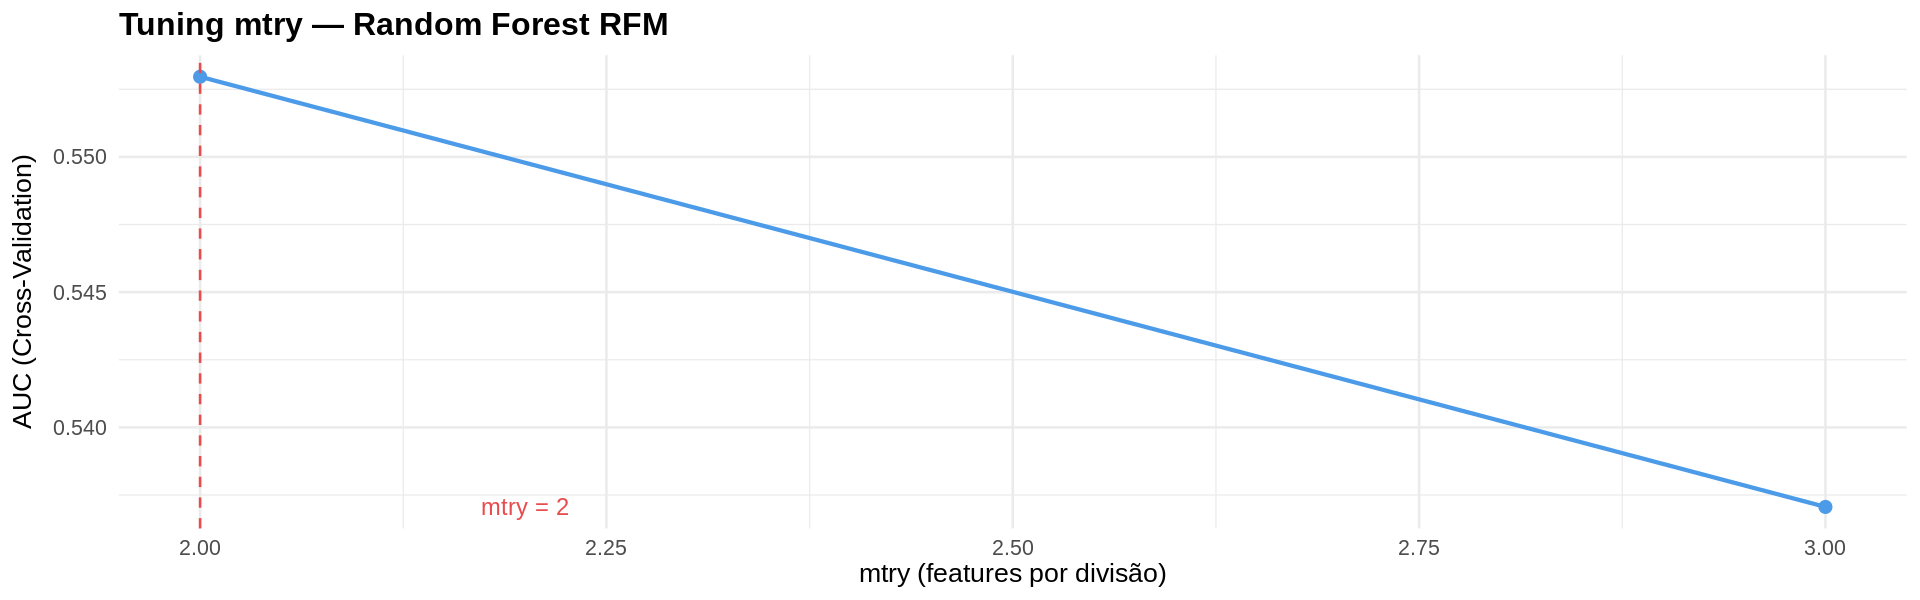

In [ ]:
ggplot(rf_model$results, aes(x = mtry, y = ROC)) +
  geom_line(color = "#4C9BE8", linewidth = 1.2) +
  geom_point(color = "#4C9BE8", size = 3) +
  geom_vline(xintercept = rf_model$bestTune$mtry,
             linetype = "dashed", color = "#E84C4C") +
  annotate("text",
           x = rf_model$bestTune$mtry + 0.2,
           y = min(rf_model$results$ROC),
           label = paste0("mtry = ", rf_model$bestTune$mtry),
           color = "#E84C4C", size = 5) +
  labs(title = "Tuning mtry — Random Forest RFM",
       x     = "mtry (features por divisão)",
       y     = "AUC (Cross-Validation)") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

Com 3 features disponíveis, o cross-validation selecionou mtry=2. O desempenho está associado a queda com mtry=3.

### 7.3 Confusion Matrix

Confusion Matrix and Statistics

               Reference
Prediction      Nao_recomprou Recomprou
  Nao_recomprou          6913       165
  Recomprou                18         0
                                          
               Accuracy : 0.9742          
                 95% CI : (0.9703, 0.9778)
    No Information Rate : 0.9767          
    P-Value [Acc > NIR] : 0.9257          
                                          
                  Kappa : -0.0046         
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.000000        
            Specificity : 0.997403        
         Pos Pred Value : 0.000000        
         Neg Pred Value : 0.976688        
             Prevalence : 0.023253        
         Detection Rate : 0.000000        
   Detection Prevalence : 0.002537        
      Balanced Accuracy : 0.498701        
                                          
     

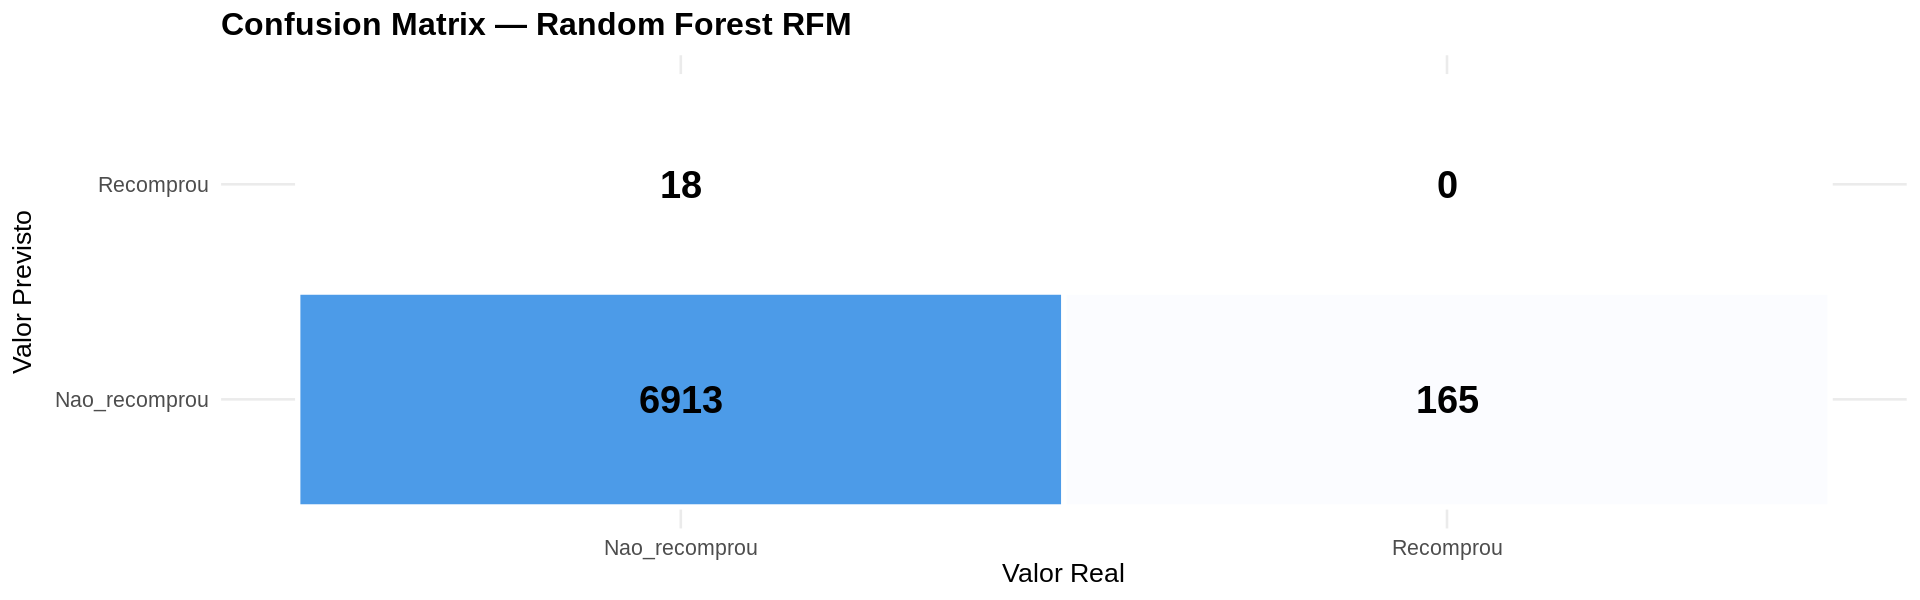

In [ ]:
pred_rf <- predict(rf_model, newdata = teste)

cm_rf <- confusionMatrix(pred_rf, teste$target_repurchase,
                         positive = "Recomprou")
print(cm_rf)

cm_table_rf <- as.data.frame(cm_rf$table)

ggplot(cm_table_rf, aes(x = Reference, y = Prediction, fill = Freq)) +
  geom_tile(colour = "white", linewidth = 1.5) +
  geom_text(aes(label = Freq), size = 8, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "#4C9BE8") +
  labs(title = "Confusion Matrix — Random Forest RFM",
       x     = "Valor Real", y = "Valor Previsto") +
  theme_minimal(base_size = 16) +
  theme(legend.position = "none",
        plot.title      = element_text(face = "bold"))

Random Forest identificou 0 recompradores reais. Kappa negativo. Desempenho abaixo do aleatório.

### 7.4 Métricas

In [ ]:
precision_rf <- cm_rf$byClass["Pos Pred Value"]
recall_rf    <- cm_rf$byClass["Sensitivity"]
f1_rf        <- 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf)
accuracy_rf  <- cm_rf$overall["Accuracy"]

cat("Accuracy: ", round(accuracy_rf,  4), "\n")
cat("Precision:", round(precision_rf, 4), "\n")
cat("Recall:   ", round(recall_rf,    4), "\n")
cat("F1-Score: ", round(f1_rf,        4), "\n")

Accuracy:  0.9742 
Precision: 0 
Recall:    0 
F1-Score:  NaN 


Recall e Precision zerados. O modelo não identificou nenhum recomprador. Accuracy de 97,4% equivalente à baseline.

### 7.5 ROC Curve

Setting direction: controls < cases



ROC-AUC — Random Forest: 0.4951 


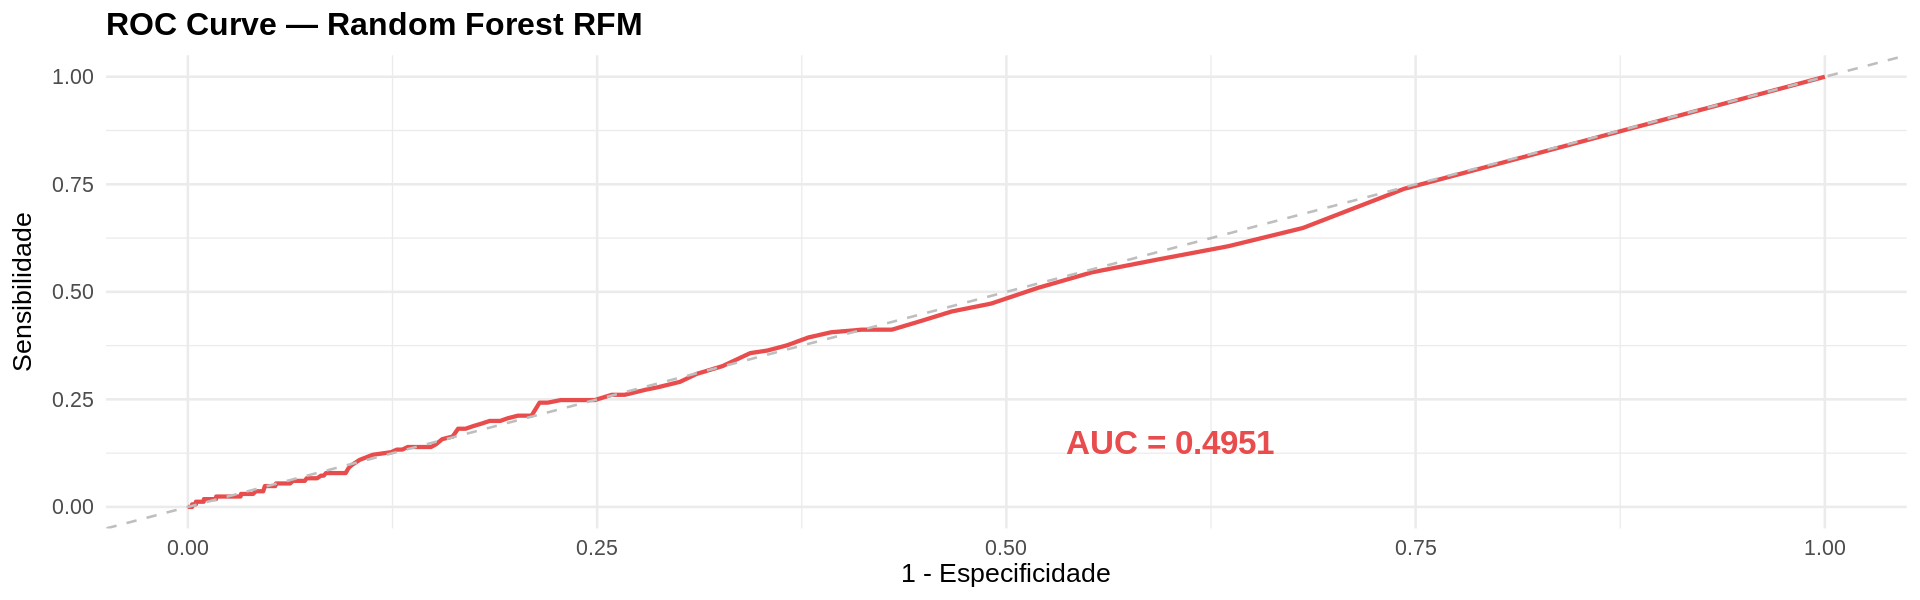

In [ ]:
prob_rf <- predict(rf_model, newdata = teste, type = "prob")[, "Recomprou"]

roc_rf <- roc(teste$target_repurchase, prob_rf,
              levels = c("Nao_recomprou", "Recomprou"))
auc_rf_roc <- round(auc(roc_rf), 4)
cat("ROC-AUC — Random Forest:", auc_rf_roc, "\n")

roc_df_rf <- data.frame(
  specificity = rev(roc_rf$specificities),
  sensitivity = rev(roc_rf$sensitivities)
)

ggplot(roc_df_rf, aes(x = 1 - specificity, y = sensitivity)) +
  geom_line(color = "#E84C4C", linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
  annotate("text", x = 0.60, y = 0.15,
           label = paste0("AUC = ", auc_rf_roc),
           size = 7, color = "#E84C4C", fontface = "bold") +
  labs(title = "ROC Curve — Random Forest RFM",
       x     = "1 - Especificidade",
       y     = "Sensibilidade") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

ROC-AUC de 0.4951. Abaixo de 0.50. Consistente com o Kappa negativo e o Recall zero.

### 7.6 PR Curve

PR-AUC  — Random Forest: 0.0233 


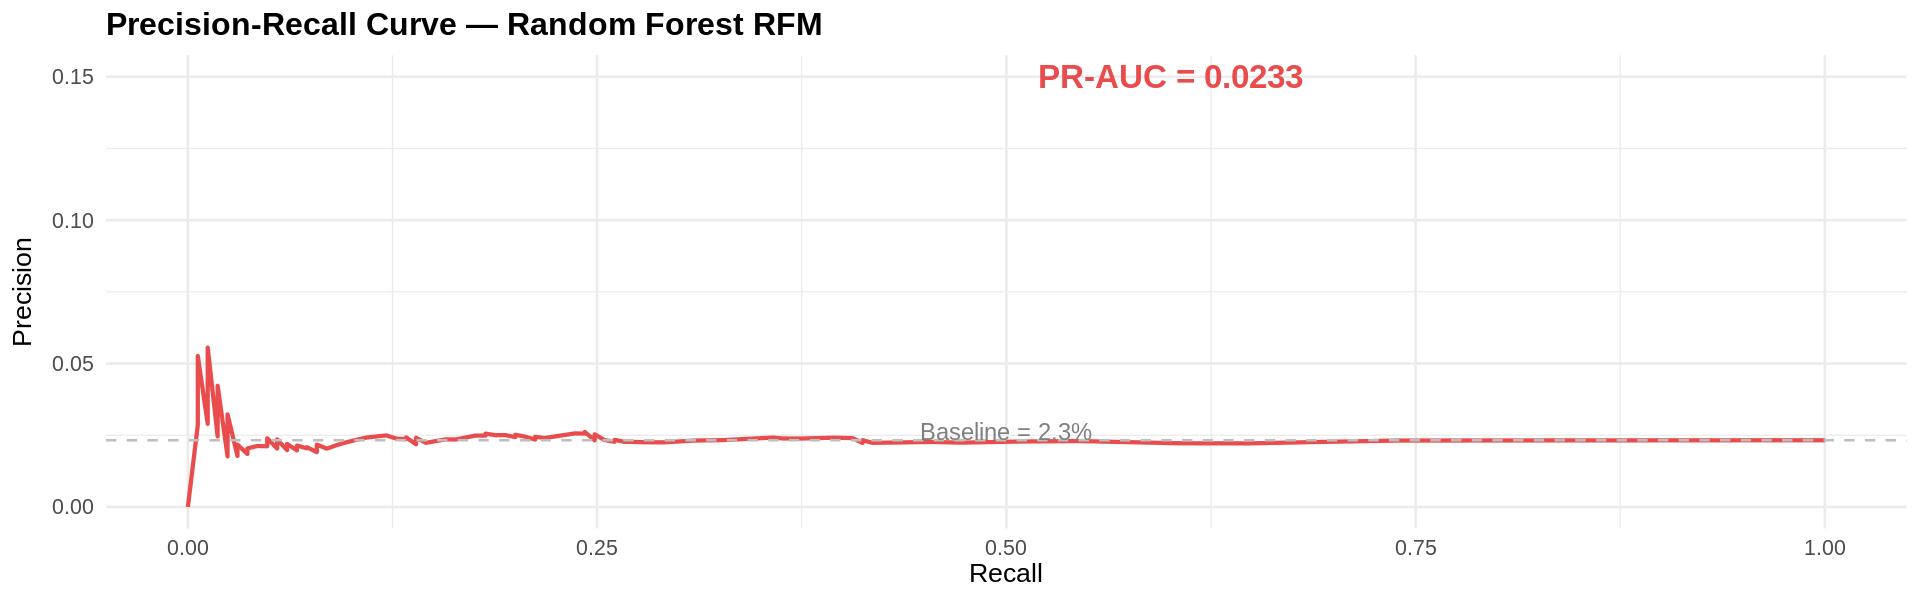

In [ ]:
pr_rf <- pr.curve(
  scores.class0 = prob_rf[teste$target_repurchase == "Recomprou"],
  scores.class1 = prob_rf[teste$target_repurchase == "Nao_recomprou"],
  curve         = TRUE
)
auc_rf_pr <- round(pr_rf$auc.integral, 4)
cat("PR-AUC  — Random Forest:", auc_rf_pr, "\n")

pr_df_rf <- data.frame(
  recall    = pr_rf$curve[, 1],
  precision = pr_rf$curve[, 2]
)

ggplot(pr_df_rf, aes(x = recall, y = precision)) +
  geom_line(color = "#E84C4C", linewidth = 1.2) +
  geom_hline(yintercept = baseline_pr,
             linetype = "dashed", color = "gray") +
  annotate("text", x = 0.5, y = baseline_pr + 0.003,
           label = paste0("Baseline = ", round(baseline_pr * 100, 1), "%"),
           color = "gray50", size = 5) +
  annotate("text", x = 0.6, y = 0.15,
           label = paste0("PR-AUC = ", auc_rf_pr),
           size = 7, color = "#E84C4C", fontface = "bold") +
  labs(title = "Precision-Recall Curve — Random Forest RFM",
       x     = "Recall", y = "Precision") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

PR-AUC de 0.023. Igual ao baseline. O Random Forest não apresentou ganho na identificação de recompradores com features RFM.

### 7.7 Feature Importance

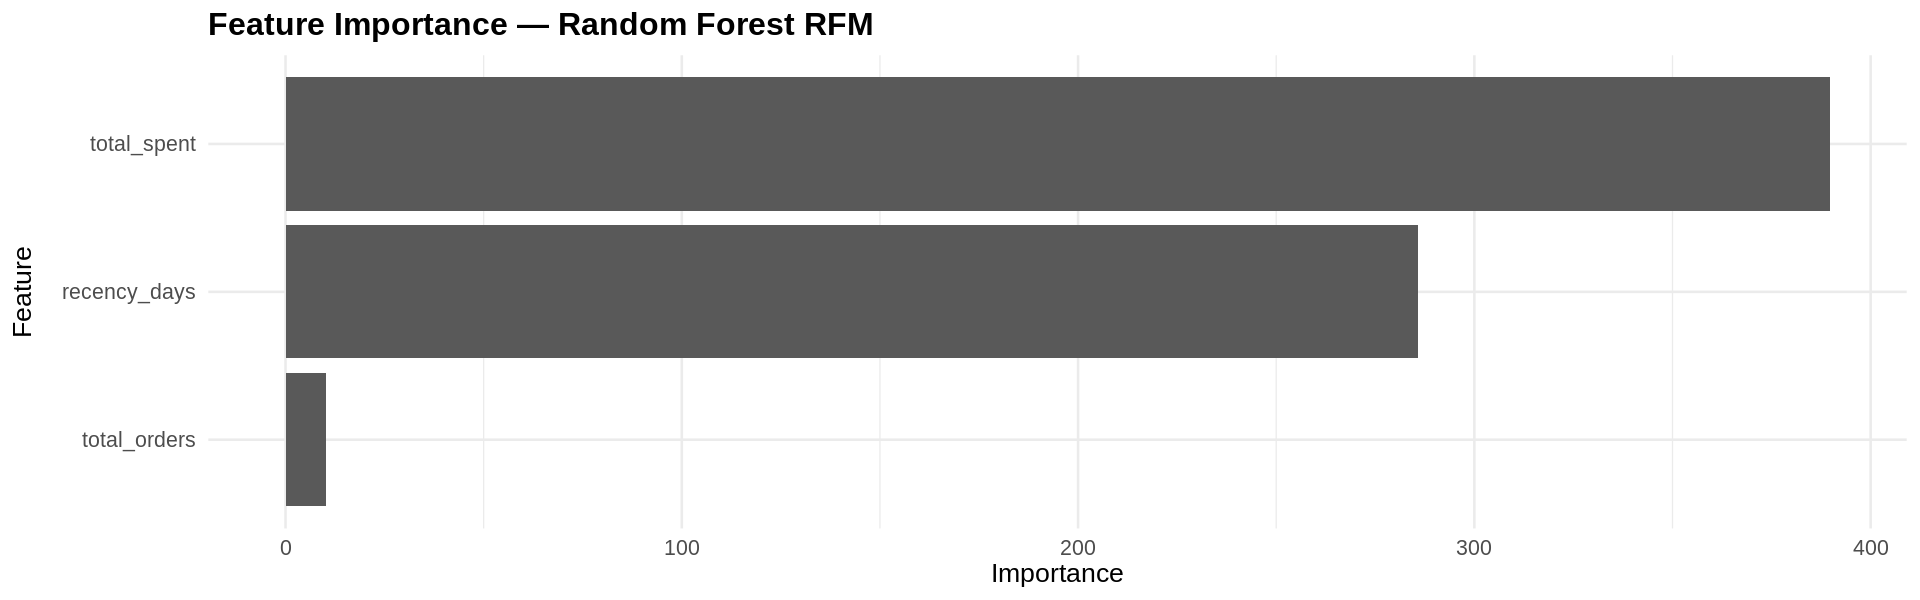

In [ ]:
importance_rf <- varImp(rf_model, scale = FALSE)

ggplot(importance_rf, top = 3) +
  labs(title = "Feature Importance — Random Forest RFM") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

`total_spent` apresenta a maior importância relativa no Random Forest. Na Decision Tree, `recency_days` foi o primeiro critério de divisão. `total_orders` apresenta importância próxima de zero em ambos os modelos.

## 8. Comparação dos Modelos

### 8.1 AUC por Fold (Cross-Validation)

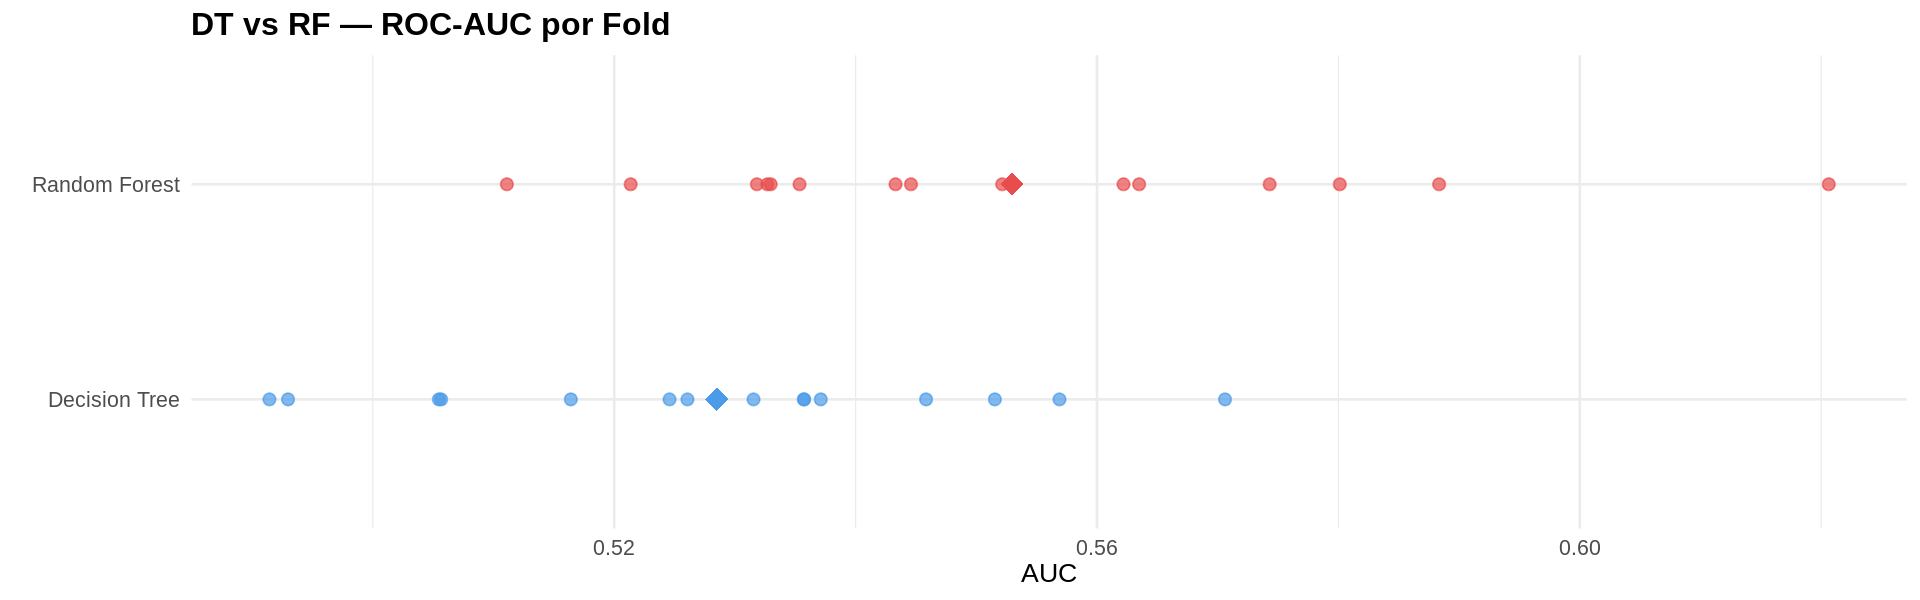

In [ ]:
resultados_cv <- resamples(list(
  "Decision Tree" = dt_model,
  "Random Forest" = rf_model
))

df_resamples <- as.data.frame(resultados_cv$values) %>%
  select(-Resample) %>%
  pivot_longer(everything(), names_to = "modelo_metrica", values_to = "valor") %>%
  filter(grepl("ROC", modelo_metrica)) %>%
  mutate(modelo = ifelse(grepl("Decision Tree", modelo_metrica),
                         "Decision Tree", "Random Forest"))

ggplot(df_resamples, aes(x = valor, y = modelo, color = modelo)) +
  geom_point(size = 3, alpha = 0.7) +
  stat_summary(fun = mean, geom = "point", size = 6, shape = 18) +
  scale_color_manual(values = c("Decision Tree" = "#4C9BE8",
                                "Random Forest" = "#E84C4C")) +
  labs(title = "DT vs RF — ROC-AUC por Fold", x = "AUC", y = NULL) +
  theme_minimal(base_size = 16) +
  theme(plot.title      = element_text(face = "bold"),
        legend.position = "none")

Distribuição da AUC em cada fold. O diamante representa a média por modelo.

### 8.2 Tabela Comparativa

In [ ]:
tabela_comparativa <- data.frame(
  Modelo    = c("Baseline", "Decision Tree RFM", "Random Forest RFM"),
  Accuracy  = c(round(mean(teste$target_repurchase == "Nao_recomprou"), 4),
                round(accuracy_dt, 4),
                round(accuracy_rf, 4)),
  Precision = c(NA,
                round(precision_dt, 4),
                round(precision_rf, 4)),
  Recall    = c(0,
                round(recall_dt, 4),
                round(recall_rf, 4)),
  F1_Score  = c(0,
                round(f1_dt, 4),
                round(f1_rf, 4)),
  ROC_AUC   = c(NA, auc_dt_roc, auc_rf_roc),
  PR_AUC    = c(round(baseline_pr, 4), auc_dt_pr, auc_rf_pr)
)

kable(tabela_comparativa,
      caption = "Comparação de Modelos IT1 — RFM",
      digits  = 4)



Table: Comparação de Modelos IT1 — RFM

|Modelo            | Accuracy| Precision| Recall| F1_Score| ROC_AUC| PR_AUC|
|:-----------------|--------:|---------:|------:|--------:|-------:|------:|
|Baseline          |   0.9767|        NA| 0.0000|    0.000|      NA| 0.0233|
|Decision Tree RFM |   0.7704|    0.0271| 0.2545|    0.049|  0.5186| 0.0250|
|Random Forest RFM |   0.9742|    0.0000| 0.0000|      NaN|  0.4951| 0.0233|

A Decision Tree apresentou PR-AUC de 0.025 contra baseline de 0.023. O Random Forest não superou o baseline. As features RFM isoladas não demonstraram capacidade relevante de separar as classes. O baixo volume de recompradores no treino está associado ao desempenho limitado observado.

### 8.3 ROC Curves Sobrepostas

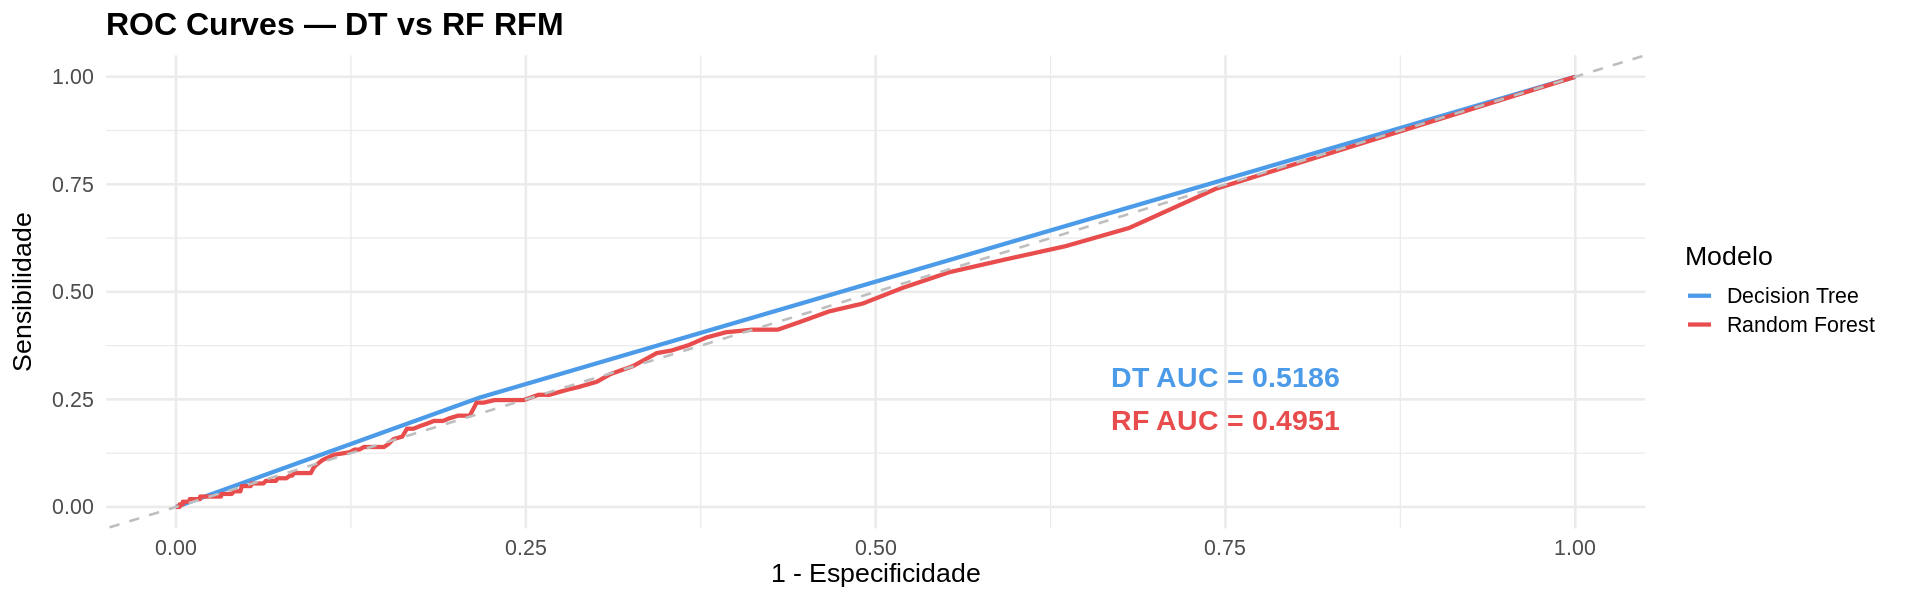

In [ ]:
roc_df_dt$modelo <- "Decision Tree"
roc_df_rf$modelo <- "Random Forest"
roc_combined     <- rbind(roc_df_dt, roc_df_rf)

ggplot(roc_combined, aes(x = 1 - specificity, y = sensitivity, color = modelo)) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
  scale_color_manual(values = c("Decision Tree" = "#4C9BE8",
                                "Random Forest" = "#E84C4C")) +
  annotate("text", x = 0.75, y = 0.30,
           label = paste0("DT AUC = ", auc_dt_roc),
           color = "#4C9BE8", size = 6, fontface = "bold") +
  annotate("text", x = 0.75, y = 0.20,
           label = paste0("RF AUC = ", auc_rf_roc),
           color = "#E84C4C", size = 6, fontface = "bold") +
  labs(title = "ROC Curves — DT vs RF RFM",
       x     = "1 - Especificidade",
       y     = "Sensibilidade",
       color = "Modelo") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

### 8.4 Análise do Threshold

Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_line()`).”


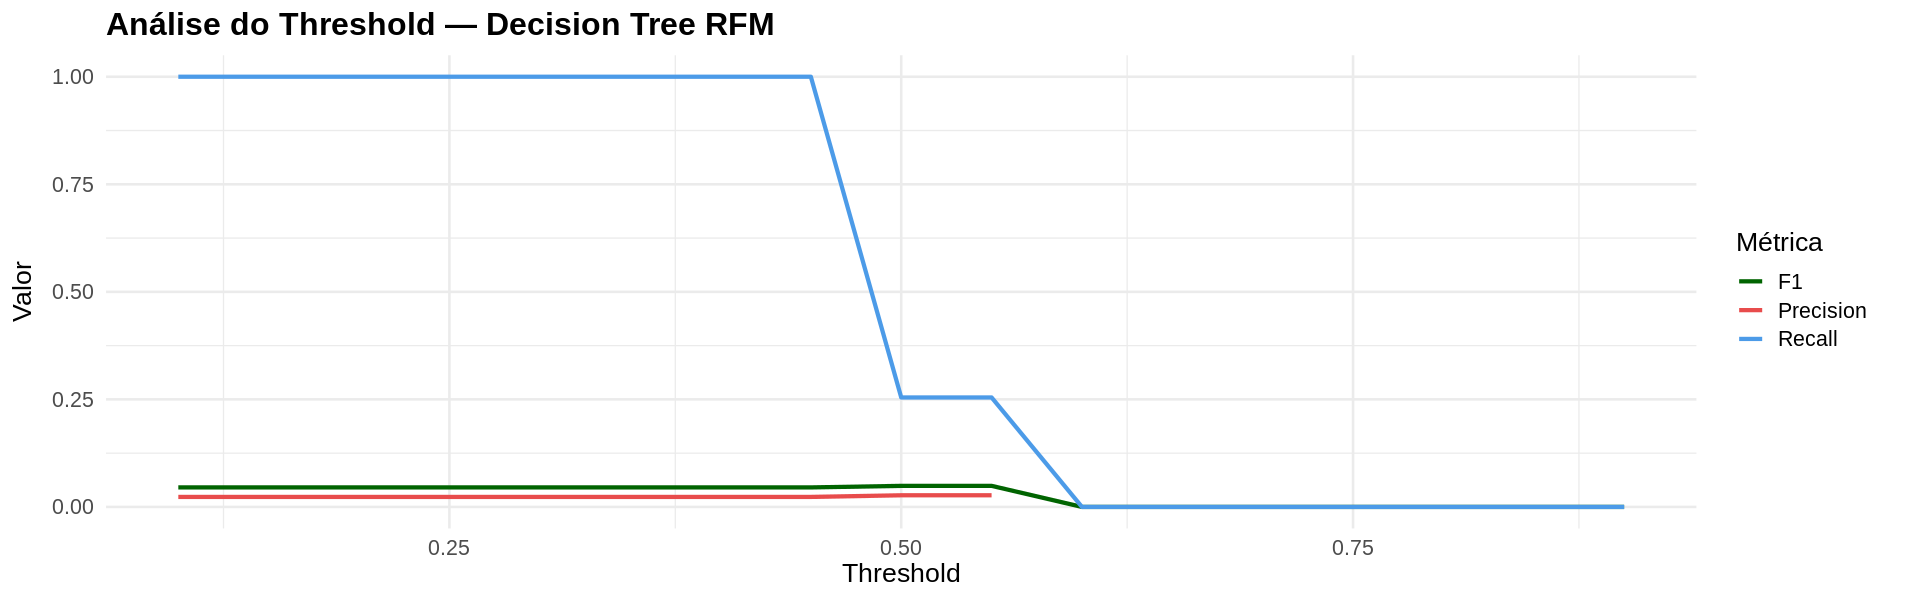

In [ ]:
thresholds           <- seq(0.1, 0.9, by = 0.05)
resultados_threshold <- data.frame()

for (t in thresholds) {
  pred_t <- factor(ifelse(prob_dt >= t, "Recomprou", "Nao_recomprou"),
                   levels = levels(teste$target_repurchase))
  cm_t   <- confusionMatrix(pred_t, teste$target_repurchase,
                             positive = "Recomprou")
  prec   <- cm_t$byClass["Pos Pred Value"]
  rec    <- cm_t$byClass["Sensitivity"]
  f1_raw <- 2 * (prec * rec) / (prec + rec)
  resultados_threshold <- rbind(resultados_threshold, data.frame(
    threshold = t,
    Precision = round(prec, 4),
    Recall    = round(rec,  4),
    F1        = round(ifelse(is.na(f1_raw), 0, f1_raw), 4)
  ))
}

resultados_threshold %>%
  pivot_longer(cols = c(Precision, Recall, F1),
               names_to = "metrica", values_to = "valor") %>%
  ggplot(aes(x = threshold, y = valor, color = metrica)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = c("Precision" = "#E84C4C",
                                "Recall"    = "#4C9BE8",
                                "F1"        = "darkgreen")) +
  labs(title  = "Análise do Threshold — Decision Tree RFM",
       x      = "Threshold", y = "Valor", color = "Métrica") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

Abaixo de 0.5 o Recall se mantém alto. O modelo sinaliza quase todos os clientes. Acima de 0.5 o Recall cai a zero. A Precision permanece próxima de zero em todos os thresholds. Não há threshold com trade-off útil neste modelo.

### 8.5 Distribuição de Probabilidades

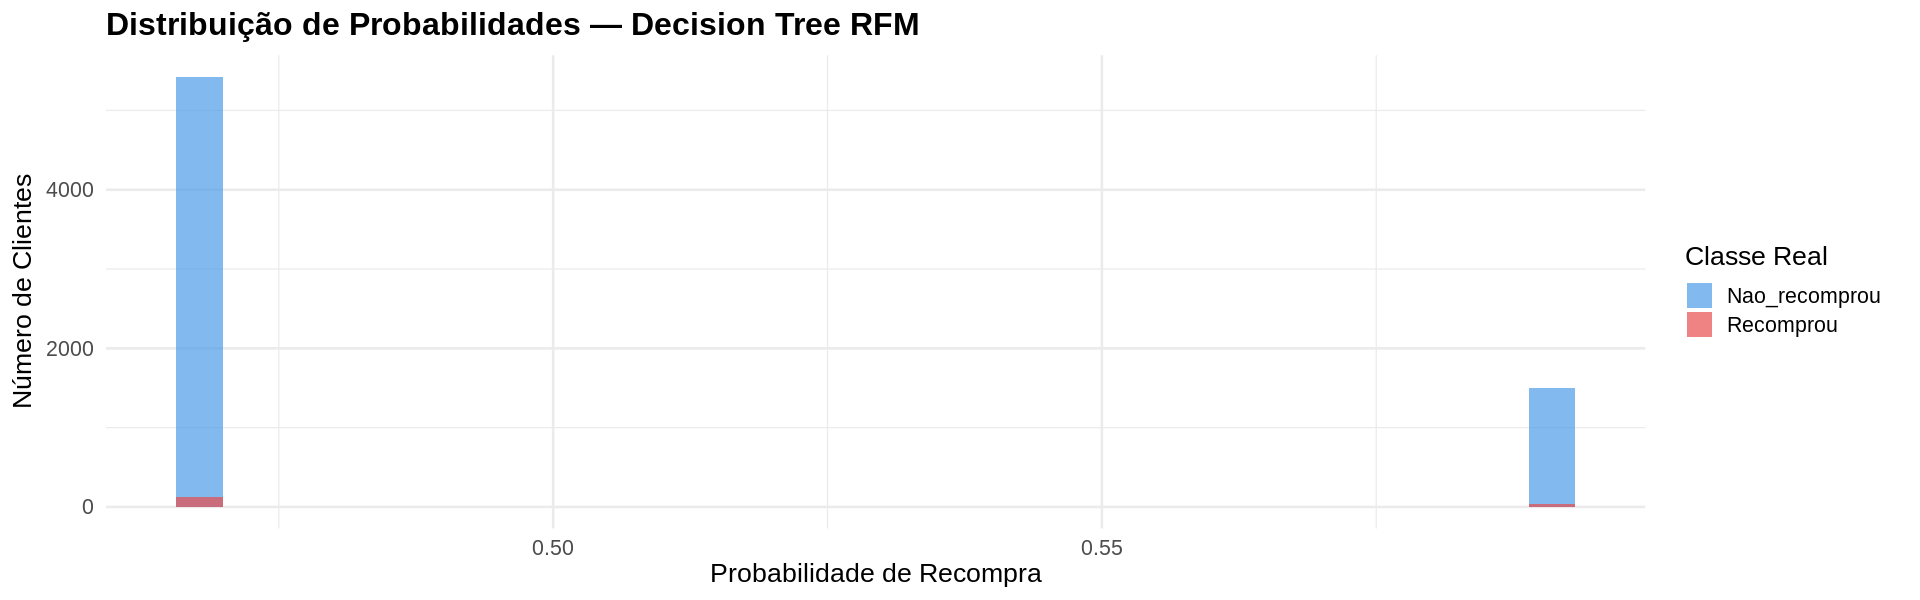

In [ ]:
prob_df <- data.frame(
  probabilidade = prob_dt,
  real          = teste$target_repurchase
)

ggplot(prob_df, aes(x = probabilidade, fill = real)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "identity") +
  scale_fill_manual(values = c("Nao_recomprou" = "#4C9BE8",
                               "Recomprou"     = "#E84C4C")) +
  labs(title = "Distribuição de Probabilidades — Decision Tree RFM",
       x     = "Probabilidade de Recompra",
       y     = "Número de Clientes",
       fill  = "Classe Real") +
  theme_minimal(base_size = 16) +
  theme(plot.title = element_text(face = "bold"))

O modelo produz apenas dois valores de probabilidade (~0.47 e ~0.57). Recompradores reais estão distribuídos nos dois grupos sem separação clara.

## 9. Análise de Erros

### 9.1 Identificação de FP e FN

In [ ]:
erros_dt      <- teste
erros_dt$prob <- prob_dt
erros_dt$pred <- pred_dt
erros_dt$real <- teste$target_repurchase

fn_dt <- erros_dt[erros_dt$real == "Recomprou"    & erros_dt$pred == "Nao_recomprou", ]
fp_dt <- erros_dt[erros_dt$real == "Nao_recomprou" & erros_dt$pred == "Recomprou",    ]

cat("Falsos negativos (oportunidades perdidas):  ", nrow(fn_dt), "\n")
cat("Falsos positivos (contactos desnecessários):", nrow(fp_dt), "\n")

Falsos negativos (oportunidades perdidas):   123 
Falsos positivos (contactos desnecessários): 1506 


123 recompradores reais não identificados (falsos negativos). 1.506 clientes sinalizados incorretamente (falsos positivos). Proporção de ~36 falsos positivos para cada verdadeiro positivo.

### 9.2 Perfil dos Erros

In [ ]:
perfil_erros <- data.frame(
  Grupo        = c("Falsos Negativos", "Falsos Positivos"),
  recency_days = c(round(mean(fn_dt$recency_days), 2),
                   round(mean(fp_dt$recency_days), 2)),
  total_orders = c(round(mean(fn_dt$total_orders), 2),
                   round(mean(fp_dt$total_orders), 2)),
  total_spent  = c(round(mean(fn_dt$total_spent),  2),
                   round(mean(fp_dt$total_spent),  2))
)

kable(perfil_erros, caption = "Perfil dos Erros — Decision Tree RFM")



Table: Perfil dos Erros — Decision Tree RFM

|Grupo            | recency_days| total_orders| total_spent|
|:----------------|------------:|------------:|-----------:|
|Falsos Negativos |       127.66|         1.07|      173.44|
|Falsos Positivos |        29.76|         1.04|      169.93|

Falsos negativos apresentam `recency_days` médio de ~127 dias. Falsos positivos apresentam ~29 dias. `total_spent` e `total_orders` com valores próximos entre os dois grupos.

## 10. Aplicação Prática

In [ ]:
prob_aplicacao <- data.frame(
  probabilidade = prob_dt,
  real          = teste$target_repurchase
) %>% arrange(desc(probabilidade))

alta_prob <- prob_aplicacao[prob_aplicacao$probabilidade > 0.7, ]
cat("Clientes com probabilidade > 0.7:", nrow(alta_prob), "\n")
cat("  Recompradores reais:            ", sum(alta_prob$real == "Recomprou"), "\n")
cat("  Precision nesse grupo:          ",
    round(mean(alta_prob$real == "Recomprou") * 100, 1), "%\n\n")

media_prob <- prob_aplicacao[prob_aplicacao$probabilidade > 0.5, ]
cat("Clientes com probabilidade > 0.5:", nrow(media_prob), "\n")
cat("  Recompradores reais:            ", sum(media_prob$real == "Recomprou"), "\n")
cat("  Precision nesse grupo:          ",
    round(mean(media_prob$real == "Recomprou") * 100, 1), "%\n")

Clientes com probabilidade > 0.7: 0 
  Recompradores reais:             0 
  Precision nesse grupo:           NaN %

Clientes com probabilidade > 0.5: 1548 
  Recompradores reais:             42 
  Precision nesse grupo:           2.7 %


Nenhum cliente atingiu probabilidade acima de 0.7. Com threshold 0.5, o modelo sinaliza 1.548 clientes dos quais 42 são recompradores reais (Precision 2.7%). Para cada recomprador identificado, o modelo sinaliza ~36 clientes que não recomprariam.

## 11. Salvar Resultados

In [ ]:
resultados_it1 <- list(
  dt_accuracy  = round(accuracy_dt,  4),
  dt_precision = round(precision_dt, 4),
  dt_recall    = round(recall_dt,    4),
  dt_f1        = round(f1_dt,        4),
  dt_rocauc    = auc_dt_roc,
  dt_prauc     = auc_dt_pr,
  rf_accuracy  = round(accuracy_rf,  4),
  rf_precision = round(precision_rf, 4),
  rf_recall    = round(recall_rf,    4),
  rf_f1        = round(f1_rf,        4),
  rf_rocauc    = auc_rf_roc,
  rf_prauc     = auc_rf_pr
)

saveRDS(resultados_it1, "resultados_it1.rds")
cat("\nResultados salvos em 'resultados_it1.rds'\n")


Resultados salvos em 'resultados_it1.rds'


Resultados salvos para comparação consolidada na IT3.

## Conclusão — Iteração 1

A primeira iteração utilizou apenas as features RFM para prever recompra no dataset da Olist.

A Decision Tree apresentou PR-AUC de 0.025 contra baseline de 0.023. O Random Forest não superou o baseline com PR-AUC de 0.023. As features RFM isoladas não demonstraram capacidade relevante de separar as classes.

O baixo volume de recompradores no treino (359 clientes, 2,3% do total) está associado ao desempenho limitado observado. Adicionar features pode apresentar ganho marginal, mas o problema do volume de dados tende a persistir nas próximas iterações.

Na IT2, features de experiência do cliente (avaliação média e atraso na entrega) serão adicionadas para verificar se há ganho nas métricas.